# Toy Experiment: Policy Distillation vs Value Distillation

This notebook compares:
1. **Policy Distillation (FQL-style)**: One-step student that distills multi-step flow
2. **Value Distillation (fbrac_inner-style)**: Time-conditioned value function V(x, t)

Environment: 2D domain [-1,1]², fixed vector field with swirl + attraction + obstacle


In [1]:
import dotenv
%load_ext dotenv
%dotenv

In [2]:
import math
import numpy as np
import jax
import jax.numpy as jnp
import jax.random as jrandom
import optax
import matplotlib.pyplot as plt
from functools import partial
from sklearn.utils import shuffle as util_shuffle
from tqdm import tqdm, trange

%matplotlib inline
plt.rcParams['figure.figsize'] = [10, 8]
plt.rcParams['figure.dpi'] = 100

print(f"Using JAX backend: {jax.default_backend()} on {jax.devices()[0]}")


Using JAX backend: gpu on cuda:0


## 1. Environment Setup


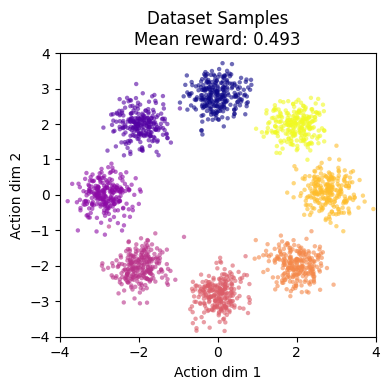

Dataset (eight_gaussians): Mean R=0.4934, Max R=1.0000


In [ ]:
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_swiss_roll

# ============================================================================
# 1. CONFIGURATION
# ============================================================================
DOMAIN_MIN, DOMAIN_MAX = -4.0, 4.0
DATASET_TYPE = 'eight_gaussians'  # Try: 'moons', 'two_spirals', 'swissroll'

# ============================================================================
# 2. EXACT REFERENCE SAMPLERS (Returns Tuple: Data, Rewards)
# ============================================================================

def _sample_eight_gaussians(n):
    scale = 4.0
    # Standard 8 centers around (0,0)
    centers = [
        (0, 1), 
        (-1./np.sqrt(2), 1./np.sqrt(2)), 
        (-1, 0), 
        (-1./np.sqrt(2), -1./np.sqrt(2)), 
        (0, -1), 
        (1./np.sqrt(2), -1./np.sqrt(2)), 
        (1, 0), 
        (1./np.sqrt(2), 1./np.sqrt(2))
    ]
    
    # Apply scale 4.0
    centers = np.array([(scale * x, scale * y) for x, y in centers]) # (8, 2)

    dataset = []
    rewards = []
    
    # Vectorized generation (faster than reference loop but mathematically identical)
    # 1. Choose centers
    indices = np.random.randint(0, 8, size=n)
    selected_centers = centers[indices]
    
    # 2. Add noise (0.5)
    noise = np.random.randn(n, 2) * 0.5
    points = selected_centers + noise
    
    # 3. Final scale (/ 1.414)
    points /= np.sqrt(2)
    
    # 4. Reference Reward: index / 7.0
    rewards = indices.astype(np.float32)[:, None] / 7.0
    
    return np.clip(points, DOMAIN_MIN, DOMAIN_MAX), rewards

def _sample_moons(n, noise=0.1):
    # 1. Generate using sklearn
    data, y = make_moons(n_samples=n, noise=noise)
    data = data.astype(np.float32)
    # 2. Transform coordinates: Scale * 2, Shift [-1, -0.2]
    data = data * 2.0 + np.array([-1.0, -0.2])
    
    # 3. Reference Reward: Class 1 (Bottom Moon) gets 1.0
    # y is (N,), make it (N, 1)
    rewards = (y > 0.5).astype(np.float32)[:, None]
    
    return np.clip(data, DOMAIN_MIN, DOMAIN_MAX), rewards

def _sample_two_spirals(n):
    # 1. Latent 'n': 0 to 3pi (1.5 turns)
    n_half = n // 2
    n_val = np.sqrt(np.random.rand(n_half, 1)) * 3 * np.pi  # "n" in reference
    
    # 2. Reference Geometry: -cos(n)*n (Mirrored)
    # Add noise similar to reference (0.1)
    d1x = -np.cos(n_val) * n_val + np.random.randn(n_half, 1) * 0.1
    d1y = np.sin(n_val) * n_val + np.random.randn(n_half, 1) * 0.1
    
    # Arm 1 & Arm 2 (Mirrored)
    arm1 = np.hstack((d1x, d1y))
    arm2 = np.hstack((-d1x, -d1y))
    
    x = np.vstack((arm1, arm2)) / 3.0
    
    # 3. Reference Reward: 1 - n/10
    # Both arms share the same 'n' distribution
    n_concat = np.concatenate([n_val, n_val], axis=0)
    rewards = np.clip(1.0 - n_concat / 10.0, 0.0, 1.0)
    
    return np.clip(x, DOMAIN_MIN, DOMAIN_MAX), rewards

def _sample_swissroll(n, noise=1.0):
    data, _ = make_swiss_roll(n_samples=n, noise=noise)
    data = data.astype(np.float32)[:, [0, 2]]
    data /= 5.0
    
    # Reference Reward: sum(data^2) / 9
    rewards = np.sum(data**2, axis=1, keepdims=True) / 9.0
    return np.clip(data, DOMAIN_MIN, DOMAIN_MAX), rewards

def sample_from_dataset(n):
    if DATASET_TYPE == 'eight_gaussians': return _sample_eight_gaussians(n)
    if DATASET_TYPE == 'moons': return _sample_moons(n)
    if DATASET_TYPE == 'two_spirals': return _sample_two_spirals(n)
    if DATASET_TYPE == 'swissroll': return _sample_swissroll(n)
    raise ValueError(f"Unknown DATASET_TYPE: {DATASET_TYPE}")

# ============================================================================
# 3. ORACLE REWARD FUNCTION (For Landscape/Noise Visualization)
# ============================================================================
def reward_fn_jnp(a):
    a = jnp.asarray(a)
    mode = DATASET_TYPE
    in_domain = (a[0] >= DOMAIN_MIN) & (a[0] <= DOMAIN_MAX) & (a[1] >= DOMAIN_MIN) & (a[1] <= DOMAIN_MAX)
    if mode == 'eight_gaussians':
        # 1. Reconstruct Latent: Reverse the final division
        #    Reference: points /= sqrt(2)
        a_scaled = a * jnp.sqrt(2)
        
        # 2. Define the 8 Centers (Scaled by 4.0)
        scale = 4.0
        centers = jnp.array([
            (0, 1), 
            (-1./jnp.sqrt(2), 1./jnp.sqrt(2)), 
            (-1, 0), 
            (-1./jnp.sqrt(2), -1./jnp.sqrt(2)), 
            (0, -1), 
            (1./jnp.sqrt(2), -1./jnp.sqrt(2)), 
            (1, 0), 
            (1./jnp.sqrt(2), 1./jnp.sqrt(2))
        ]) * scale

        # 3. Find Nearest Center
        #    Calculate distance to all 8 centers
        dists = jnp.sum((a_scaled[None, :] - centers)**2, axis=1) # Shape (8,)
        nearest_idx = jnp.argmin(dists)
        
        # 4. Reference Reward: index / 7.0
        val = nearest_idx.astype(jnp.float32) / 7.0
        return jnp.where(in_domain, val, 0.0)
    if mode == 'moons':
        a_orig = (a - jnp.array([-1.0, -0.2])) / 2.0
        dist_c0 = jnp.sum((a_orig - jnp.array([0.0, 0.0]))**2)
        dist_c1 = jnp.sum((a_orig - jnp.array([1.0, -0.5]))**2)
        val = jnp.where(dist_c1 < dist_c0, 1.0, 0.0)
        return jnp.where(in_domain, val, 0.0)

    if mode == 'two_spirals':
        # Reconstruct n ~ 3 * |a|
        n_est = 3.0 * jnp.sqrt(jnp.sum(a**2))
        val = jnp.clip(1.0 - n_est / 10.0, 0.0, 1.0)
        
        # Manifold mask for visualization clarity
        r_vals = jnp.linspace(0.0, 3.0 * jnp.pi, 100)
        pts = jnp.stack([-jnp.cos(r_vals)*r_vals, jnp.sin(r_vals)*r_vals], axis=1) / 3.0
        d = jnp.min(jnp.sum((pts - a)**2, axis=1))
        d2 = jnp.min(jnp.sum((-pts - a)**2, axis=1))
        mask = jnp.exp(-0.5 * jnp.minimum(d, d2) / (0.15**2))
        return jnp.where(in_domain, val * mask, 0.0)

    if mode == 'swissroll':
        val = jnp.sum(a**2) / 9.0
        return jnp.where(in_domain, val, 0.0)

    return 0.0

reward_fn_vec = jax.vmap(reward_fn_jnp, in_axes=(0,))
def reward_fn(a): return float(reward_fn_jnp(jnp.asarray(a)))
def plot_reward_landscape(ax, res=50):
    xs = np.linspace(DOMAIN_MIN, DOMAIN_MAX, res)
    ys = np.linspace(DOMAIN_MIN, DOMAIN_MAX, res)
    X, Y = np.meshgrid(xs, ys)
    grid = np.stack([X, Y], axis=-1).reshape(-1, 2)
    R = np.array(reward_fn_vec(jnp.asarray(grid))).reshape(X.shape)
    return ax.contourf(X, Y, R, levels=30, cmap='viridis', alpha=0.8)

# ============================================================================
# 4. UPDATED VISUALIZATION SCRIPT
# ============================================================================

# Sample from dataset (Unpacking tuple: data, rewards)
np.random.seed(42)
dataset_samples, dataset_rewards = sample_from_dataset(2000)
dataset_rewards = dataset_rewards.flatten()  # Flatten for scatter plot c argument

plt.figure(figsize=(4,4))
plt.scatter(dataset_samples[:, 0], dataset_samples[:, 1], 
                       c=dataset_rewards, cmap='plasma', s=10, alpha=0.6, edgecolors='none')
plt.title(f"Dataset Samples\nMean reward: {dataset_rewards.mean():.3f}")
plt.xlabel('Action dim 1'); plt.ylabel('Action dim 2')
plt.xlim(-4 ,4)
plt.ylim(-4 ,4)

plt.tight_layout()
plt.show()

# Statistics
print(f"Dataset ({DATASET_TYPE}): Mean R={dataset_rewards.mean():.4f}, Max R={dataset_rewards.max():.4f}")

In [4]:
# ============================================================================
# Generate Training Data
# ============================================================================
# Dataset: clean samples x_1 from the dataset distribution
# Reward: R(x_1) explicitly returned by the reference sampler

np.random.seed(0)
key_data = jax.random.PRNGKey(0)

N_DATA = 10000
FLOW_STEPS = 64

# 1. CALL SAMPLER & UNPACK TUPLE
# sample_from_dataset now returns (data, rewards)
x_1_data, rewards_data = sample_from_dataset(N_DATA)

# 2. FLATTEN REWARDS
# The sampler returns (N, 1), but for statistics/printing we usually want (N,)
rewards_data = np.array(rewards_data).flatten()

print(f"Dataset: {N_DATA} clean samples from {DATASET_TYPE}")
print(f"Reward range: [{rewards_data.min():.4f}, {rewards_data.max():.4f}]")
print(f"Mean reward: {rewards_data.mean():.4f}")
print(f"High reward (>0.3): {(rewards_data > 0.3).mean():.2%}")

Dataset: 10000 clean samples from eight_gaussians
Reward range: [0.0000, 1.0000]
Mean reward: 0.4955
High reward (>0.3): 62.45%


In [5]:
# ============================================================================
# MODEL DEFINITIONS (JAX)
# ============================================================================
# All networks are simple MLPs expressed as pure JAX functions.


def init_mlp(layer_sizes, key, scale=0.02):
    """Xavier-style init with small scale to keep dynamics stable."""
    keys = jrandom.split(key, len(layer_sizes) - 1)
    params = []
    for k, (n_in, n_out) in zip(keys, zip(layer_sizes[:-1], layer_sizes[1:])):
        w = jrandom.normal(k, (n_in, n_out)) * scale
        b = jnp.zeros((n_out,))
        params.append({'w': w, 'b': b})
    return params


def apply_mlp(params, x, activation=jax.nn.relu, use_residual=False):
    for i, layer in enumerate(params):
        x = jnp.dot(x, layer['w']) + layer['b']
        if i < len(params) - 1:
            x = activation(x)
    if use_residual:
        x = x + x
    return x


def fourier_time_embed(t, embed_dim=64, max_freq=512.0):
    """
    Fourier positional embedding for time.
    Maps scalar t ∈ [0, 1] to a embed_dim-dimensional vector using sinusoidal features.
    
    Args:
        t: Time values of shape (batch, 1)
        embed_dim: Dimension of the embedding (must be even)
        max_freq: Maximum frequency for the Fourier features
        
    Returns:
        Embedding of shape (batch, embed_dim)
    """
    # Frequencies: log-spaced from 1 to max_freq
    half_dim = embed_dim // 2
    freqs = jnp.exp(jnp.linspace(0.0, jnp.log(max_freq), half_dim))
    # Apply frequencies to time: (batch, 1) * (half_dim,) -> (batch, half_dim)
    args = t * freqs[None, :]
    # Concatenate sin and cos: (batch, embed_dim)
    embedding = jnp.concatenate([jnp.sin(args), jnp.cos(args)], axis=-1)
    return embedding


def flow_forward(flow_params, x, t):
    xt = jnp.concatenate([x, t], axis=-1)
    return apply_mlp(flow_params, xt)


def flow_forward_with_time_embed(flow_params, x, t, time_embed_dim=64):
    """Flow forward with Fourier time embedding."""
    t_embed = fourier_time_embed(t, embed_dim=time_embed_dim)
    xt = jnp.concatenate([x, t_embed], axis=-1)
    return apply_mlp(flow_params, xt)


def onestep_forward(policy_params, z):
    return apply_mlp(policy_params, z)


def critic_forward(critic_params, a, use_residual=False):
    return apply_mlp(critic_params, a, use_residual=use_residual).squeeze(-1)


def inner_critic_forward(inner_params, x, t, use_residual=False):
    xt = jnp.concatenate([x, t], axis=-1)
    return apply_mlp(inner_params, xt, use_residual=use_residual).squeeze(-1)


def integrate_flow_from(flow_params, x, t_start, steps=10, full_simulate=False):
    """Integrate flow starting at (x, t_start) to t=1."""
    def step_fn(carry, _):
        x_curr, t_curr = carry
        if full_simulate:
            dt = (1.0 - t_curr) / steps
        else:
            dt = jnp.minimum(1.0 - t_curr, 1.0 / steps)
        v = flow_forward(flow_params, x_curr, t_curr)
        x_next = x_curr + v * dt
        t_next = t_curr + dt
        x_next = jnp.clip(x_next, DOMAIN_MIN, DOMAIN_MAX)
        return (x_next, t_next), None

    (x_final, _), _ = jax.lax.scan(step_fn, (x, t_start), None, length=steps)
    return x_final


def integrate_flow(flow_params, z, steps=10):
    t0 = jnp.zeros((z.shape[0], 1))
    return integrate_flow_from(flow_params, z, t0, steps=steps)


print("Models redefined in JAX!")
print("  - FlowPolicy / OneStep / Critics are functional MLPs")
print("  - integrate_flow_from(): integrates from (x, t) → t=1")
print("  - Optimizer: optax.adam")


Models redefined in JAX!
  - FlowPolicy / OneStep / Critics are functional MLPs
  - integrate_flow_from(): integrates from (x, t) → t=1
  - Optimizer: optax.adam


## 4. Training Functions


In [6]:
# ============================================================================
# FQL ACTOR-CRITIC TRAINING (JAX)
# ============================================================================
# Components: FlowPolicy (teacher), OneStepPolicy, OuterCritic
# Policy improvement: maximize Q(policy(z))

batch_size = 1024

def plot_training_progress(flow_params, policy_params, critic_params, epoch, flow_steps, n_samples=512):
    """Plot the current model predictions during training."""
    from IPython.display import display, clear_output
    
    # Sample actions from flow and one-step policy
    z_eval = jrandom.normal(jrandom.PRNGKey(999), (n_samples, 2))
    flow_actions = np.array(integrate_flow(flow_params, z_eval, steps=flow_steps))
    policy_actions = np.array(onestep_forward(policy_params, z_eval))
    
    # Compute rewards
    flow_rewards = np.array(reward_fn_vec(jnp.asarray(flow_actions)))
    policy_rewards = np.array(reward_fn_vec(jnp.asarray(policy_actions)))
    
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    
    # 2. One-Step Policy
    ax2 = axes[0]
    sc2 = ax2.scatter(policy_actions[:, 0], policy_actions[:, 1], c=policy_rewards, 
                      cmap='plasma', s=15, alpha=0.7, edgecolors='none')
    ax2.set_title(f'One-Step Policy (Epoch {epoch})\nMean R: {policy_rewards.mean():.4f}')
    ax2.set_xlabel('x₁'); ax2.set_ylabel('x₂')
    ax2.set_xlim(DOMAIN_MIN, DOMAIN_MAX); ax2.set_ylim(DOMAIN_MIN, DOMAIN_MAX)
    ax2.set_aspect('equal')
    
    # 3. Critic Q-values heatmap
    ax3 = axes[1]
    resolution = 50
    x = np.linspace(DOMAIN_MIN, DOMAIN_MAX, resolution)
    y = np.linspace(DOMAIN_MIN, DOMAIN_MAX, resolution)
    X, Y = np.meshgrid(x, y)
    positions = jnp.array(np.stack([X.ravel(), Y.ravel()], axis=-1))
    q_values = np.array(critic_forward(critic_params, positions)).reshape(resolution, resolution)
    im3 = ax3.imshow(q_values, extent=[DOMAIN_MIN, DOMAIN_MAX, DOMAIN_MIN, DOMAIN_MAX], 
                     origin='lower', cmap='viridis', aspect='equal')
    ax3.set_title(f'Critic Q(a) (Epoch {epoch})')
    ax3.set_xlabel('x₁'); ax3.set_ylabel('x₂')
    
    plt.tight_layout()
    plt.show()

In [7]:

def train_fql(x_1_data, rewards_data, epochs=2000, lr=1e-3, alpha=1.0, flow_steps=10, hidden=128, plot_every=None):
    """
    FQL-style actor-critic training (JAX) with jitted update step.
    1. Train flow teacher (BC via flow matching)
    2. Train outer critic Q(a) → R(a)
    3. Train one-step policy: distillation + Q-maximization
    
    Args:
        plot_every: If set, plot model predictions every `plot_every` epochs.
    """
    key = jrandom.PRNGKey(42)
    X1 = jnp.asarray(x_1_data)
    R = jnp.asarray(rewards_data)

    k1, k2, k3 = jrandom.split(key, 3)
    flow_params = init_mlp([3, hidden, hidden, hidden, 2], k1)
    policy_params = init_mlp([2, hidden, hidden, hidden, 2], k2)
    critic_params = init_mlp([2, hidden, hidden, hidden, 1], k3)

    flow_opt = optax.adam(lr)
    policy_opt = optax.adam(lr)
    critic_opt = optax.adam(lr)
    flow_opt_state = flow_opt.init(flow_params)
    policy_opt_state = policy_opt.init(policy_params)
    critic_opt_state = critic_opt.init(critic_params)

    @partial(jax.jit, static_argnames=("flow_steps", "alpha", "batch_size"))
    def step(state, key, flow_steps, alpha, batch_size):
        flow_params, policy_params, critic_params, flow_opt_state, policy_opt_state, critic_opt_state = state
        key, k_idx, k_z, k_t, k_pol = jrandom.split(key, 5)
        idx = jrandom.choice(k_idx, X1.shape[0], shape=(batch_size,), replace=False)
        x_1 = X1[idx]
        r = R[idx]

        z = jrandom.normal(k_z, (batch_size, 2))
        t = jrandom.uniform(k_t, (batch_size, 1))
        x_t = (1 - t) * z + t * x_1
        u_target = x_1 - z

        def flow_loss_fn(params):
            v_pred = flow_forward(params, x_t, t)
            return jnp.mean((v_pred - u_target) ** 2)

        flow_loss, flow_grads = jax.value_and_grad(flow_loss_fn)(flow_params)
        flow_updates, flow_opt_state = flow_opt.update(flow_grads, flow_opt_state, flow_params)
        flow_params = optax.apply_updates(flow_params, flow_updates)

        def critic_loss_fn(params):
            q_pred = critic_forward(params, x_1)
            return jnp.mean((q_pred - r) ** 2)

        critic_loss, critic_grads = jax.value_and_grad(critic_loss_fn)(critic_params)
        critic_updates, critic_opt_state = critic_opt.update(critic_grads, critic_opt_state, critic_params)
        critic_params = optax.apply_updates(critic_params, critic_updates)

        z_policy = jrandom.normal(k_pol, (batch_size, 2))
        teacher_output = jax.lax.stop_gradient(integrate_flow(flow_params, z_policy, steps=flow_steps))

        def policy_loss_fn(params):
            policy_output = onestep_forward(params, z_policy)
            distill_loss = jnp.mean((policy_output - teacher_output) ** 2)
            q_at_policy = critic_forward(critic_params, policy_output)
            return alpha * distill_loss - jnp.mean(q_at_policy), (distill_loss, jnp.mean(q_at_policy))

        (policy_loss, (distill_loss, q_val)), policy_grads = jax.value_and_grad(policy_loss_fn, has_aux=True)(policy_params)
        policy_updates, policy_opt_state = policy_opt.update(policy_grads, policy_opt_state, policy_params)
        policy_params = optax.apply_updates(policy_params, policy_updates)

        logs = (
            flow_loss,
            critic_loss,
            distill_loss,
            q_val,
            policy_loss,
        )
        new_state = (flow_params, policy_params, critic_params, flow_opt_state, policy_opt_state, critic_opt_state)
        return new_state, (key, logs)

    history = {
        'flow_loss': [], 'critic_loss': [],
        'policy_distill': [], 'policy_q': [], 'policy_total': []
    }
    if plot_every:
        num_plots = epochs // plot_every
        fig, axes = plt.subplots(2, num_plots, figsize=(num_plots*5, 8))
    
    cnt = 0
    n_samples = 512
    # NOTE: Don't shadow the flow_steps parameter!
    state = (flow_params, policy_params, critic_params, flow_opt_state, policy_opt_state, critic_opt_state)
    for epoch in trange(epochs, desc="FQL (JAX)"):
        state, (key, logs) = step(state, key, flow_steps, alpha, batch_size)
        flow_loss, critic_loss, distill_loss, q_val, policy_loss = logs
        history['flow_loss'].append(float(flow_loss))
        history['critic_loss'].append(float(critic_loss))
        history['policy_distill'].append(float(distill_loss))
        history['policy_q'].append(float(q_val))
        history['policy_total'].append(float(policy_loss))
        
        # Plot intermediate results
        if plot_every is not None and (epoch + 1) % plot_every == 0:
            flow_params_curr, policy_params_curr, critic_params_curr, _, _, _ = state
            z_eval = jrandom.normal(jrandom.PRNGKey(999), (n_samples, 2))
            # FIX: Use _curr params instead of initial params
            flow_actions = np.array(integrate_flow(flow_params_curr, z_eval, steps=flow_steps))
            policy_actions = np.array(onestep_forward(policy_params_curr, z_eval))
            
            ax = axes[0, cnt]
            sc2 = ax.scatter(policy_actions[:, 0], policy_actions[:, 1], s=15, alpha=0.7, edgecolors='none')
            ax.set_title(f'One-Step Policy (Epoch {epoch + 1})')
            ax.set_xlabel('x₁'); ax.set_ylabel('x₂')
            ax.set_xlim(DOMAIN_MIN, DOMAIN_MAX); ax.set_ylim(DOMAIN_MIN, DOMAIN_MAX)
            ax.set_aspect('equal')

            # Critic Q-values heatmap
            ax3 = axes[1, cnt]
            resolution = 50
            x = np.linspace(DOMAIN_MIN, DOMAIN_MAX, resolution)
            y = np.linspace(DOMAIN_MIN, DOMAIN_MAX, resolution)
            X, Y = np.meshgrid(x, y)
            positions = jnp.array(np.stack([X.ravel(), Y.ravel()], axis=-1))
            # FIX: Use critic_params_curr instead of critic_params
            q_values = np.array(critic_forward(critic_params_curr, positions)).reshape(resolution, resolution)
            im3 = ax3.imshow(q_values, extent=[DOMAIN_MIN, DOMAIN_MAX, DOMAIN_MIN, DOMAIN_MAX], 
                            origin='lower', cmap='viridis', aspect='equal')
            ax3.set_title(f'Critic Q(a) (Epoch {epoch + 1})')
            ax3.set_xlabel('x₁'); ax3.set_ylabel('x₂')

            cnt += 1

    flow_params, policy_params, critic_params, _, _, _ = state
    if plot_every is not None:
        plt.tight_layout()
        plt.show()
    return flow_params, policy_params, critic_params, history

### TVL training function

In [8]:
def train_fbrac_inner(x_1_data, rewards_data, epochs=2000, lr=1e-3, alpha=1.0, flow_steps=10, hidden=128, plot_every=None, 
fbrac_inner_policy_loss_type="grad_align", use_time_embed=False, time_embed_dim=64, 
max_time_penalty=0.0,time_weight=True, expectile=0.5, use_residual=False):
    """
    FBRAC-Inner: Flow-based actor-critic with inner (time-conditioned) critic.
    
    Args:
        use_time_embed: If True, use Fourier time embedding for inner critic (not policy)
        time_embed_dim: Dimension of the Fourier time embedding (default 64)
    """
    key = jrandom.PRNGKey(123)
    X1 = jnp.asarray(x_1_data)
    R = jnp.asarray(rewards_data)

    k1, k2, k3, k4 = jrandom.split(key, 4)
    # Flow network input: x (2D) + time (1D or time_embed_dim)
    # Policy now uses Fourier time embedding
    flow_input_dim = 2 + 1 # Scalar time for policy
    # Inner critic input: x (2D) + time (1D or time_embed_dim)  
    inner_input_dim = 2 + (time_embed_dim if use_time_embed else 1)
    
    flow_params = init_mlp([flow_input_dim, hidden, hidden, hidden, 2], k1)
    inner_params = init_mlp([inner_input_dim, hidden, hidden, hidden, 1], k2)
    outer_params = init_mlp([2, hidden, hidden, hidden, 1], k3)
    
    # Define local forward functions
    # Policy (flow) uses Fourier time embedding
    def _flow_forward(params, x, t):
        # t_embed = fourier_time_embed(t, embed_dim=time_embed_dim)
        xt = jnp.concatenate([x, t], axis=-1)
        return apply_mlp(params, xt)
    
    # Inner critic optionally uses time embedding
    def _inner_critic_forward(params, x, t, use_residual=False):
        if use_time_embed:
            t_embed = fourier_time_embed(t, embed_dim=time_embed_dim)
            xt = jnp.concatenate([x, t_embed], axis=-1)
        else:
            xt = jnp.concatenate([x, t], axis=-1)
        return apply_mlp(params, xt, use_residual=use_residual).squeeze(-1)

    flow_opt = optax.adam(lr)
    inner_opt = optax.adam(lr)
    outer_opt = optax.adam(lr)
    flow_opt_state = flow_opt.init(flow_params)
    inner_opt_state = inner_opt.init(inner_params)
    outer_opt_state = outer_opt.init(outer_params)
    
    # Pre-create figure for grid plotting
    n_samples = 512
    if plot_every:
        num_plots = epochs // plot_every
        fig, axes = plt.subplots(2, num_plots, figsize=(num_plots*5, 8))
        cnt = 0

    dt_const = 1.0 / flow_steps

    distillation_batch_scale = 1

    # Local integrate functions that use the time-embed-aware forward
    def _integrate_flow_from(flow_params, x, t_start, steps=10):
        """Integrate flow starting at (x, t_start) to t=1 using local _flow_forward."""
        def step_fn(carry, _):
            x_curr, t_curr = carry
            dt = jnp.minimum(1.0 - t_curr, 1.0 / steps)
            v = _flow_forward(flow_params, x_curr, t_curr)
            x_next = x_curr + v * dt
            t_next = t_curr + dt
            x_next = jnp.clip(x_next, DOMAIN_MIN, DOMAIN_MAX)
            return (x_next, t_next), None
        (x_final, _), _ = jax.lax.scan(step_fn, (x, t_start), None, length=steps)
        return x_final
    
    def _integrate_flow(flow_params, z, steps=10):
        """Integrate flow from t=0 to t=1 using local _flow_forward."""
        t0 = jnp.zeros((z.shape[0], 1))
        return _integrate_flow_from(flow_params, z, t0, steps=steps)

    @partial(jax.jit, static_argnames=("flow_steps", "alpha", "batch_size"))
    def step(state, key, flow_steps, alpha, batch_size):
        flow_params, inner_params, outer_params, flow_opt_state, inner_opt_state, outer_opt_state = state
        key, k_idx, k_noise, k_t, k_pol1, k_pol2, _, _ = jrandom.split(key, 8)
        idx = jrandom.choice(k_idx, X1.shape[0], shape=(batch_size,), replace=False)
        x_1 = X1[idx]
        r = R[idx]

        # outer critic on clean actions
        def outer_loss_fn(params):
            q_pred = critic_forward(params, x_1, use_residual=use_residual)
            
            return jnp.mean((q_pred - r) ** 2)

        outer_loss, outer_grads = jax.value_and_grad(outer_loss_fn)(outer_params)
        outer_updates, outer_opt_state = outer_opt.update(outer_grads, outer_opt_state, outer_params)
        outer_params = optax.apply_updates(outer_params, outer_updates)

        # critic distillation (inner) from outer critic along flow + boundary
        x_0 = jrandom.normal(k_noise, (batch_size*distillation_batch_scale, 2))
        t = jrandom.uniform(k_t, (batch_size*distillation_batch_scale, 1), minval=0.0, maxval=1.0)
        x_t = (1 - t) * x_0 + t * x_1.repeat(distillation_batch_scale, axis=0)
        x_1_pred = _integrate_flow_from(flow_params, x_t, t, steps=flow_steps)

        time_penalty = max_time_penalty * (1.0 - t)
        target_r = jax.lax.stop_gradient(critic_forward(outer_params, x_1_pred, use_residual=use_residual))  - time_penalty # ODE simulation
        # one step forward
        # dt = jnp.minimum(1.0 - t, 1.0/flow_steps)
        # x_t_next = x_t + _flow_forward(flow_params, x_t, t) * dt
        # target_r = jax.lax.stop_gradient(_inner_critic_forward(inner_params, x_t_next, t + dt))

        # target_r = jax.lax.stop_gradient(critic_forward(outer_params, x_1)) # Optimal Transport

        def expectile_loss(diff, expectile):
            """Asymmetric squared loss for expectile regression."""
            weight = jnp.where(diff >= 0, expectile, (1 - expectile))
            return weight * (diff ** 2)

        def critic_loss_fn(params):
            v_pred = _inner_critic_forward(params, x_t, t, use_residual=use_residual)
            # distill_loss = jnp.mean((v_pred - target_r) ** 2)
            distill_loss = jnp.mean(expectile_loss(v_pred - target_r, expectile))
            # v_clean_pred = _inner_critic_forward(params, x_1, jnp.ones_like(t))
            # boundary_loss = jnp.mean((v_clean_pred - r) ** 2)
            return distill_loss, (distill_loss, 0.0)

        (critic_loss, (distill_loss, _)), critic_grads = jax.value_and_grad(critic_loss_fn, has_aux=True)(inner_params)
        inner_updates, inner_opt_state = inner_opt.update(critic_grads, inner_opt_state, inner_params)
        inner_params = optax.apply_updates(inner_params, inner_updates)

        # flow update
        x_0_policy = jrandom.normal(k_pol1, (batch_size, 2))
        t_policy = jrandom.uniform(k_pol2, (batch_size, 1))
        x_t_policy = (1 - t_policy) * x_0_policy + t_policy * x_1
        u_target_policy = x_1 - x_0_policy
        if fbrac_inner_policy_loss_type == "grad_align":

            def flow_loss_fn(params):
                pred_vel = _flow_forward(params, x_t_policy, t_policy)
                # 1. BC Loss (Base Requirement)
                bc_loss = jnp.mean((pred_vel - u_target_policy) ** 2)
                
                # 2. Q maximization
                def value_sum_fn(x_in):
                    # Sum for batch gradient computation
                    return jnp.sum(_inner_critic_forward(inner_params, x_in, t_policy, use_residual=use_residual))

                grad_v = jax.grad(value_sum_fn)(x_t_policy)
                grad_v = jax.lax.stop_gradient(grad_v)
                alignment = jnp.sum(pred_vel * grad_v, axis=-1)
                
                q_loss = -jnp.mean(alignment)

                total_loss = alpha * bc_loss + q_loss
                return total_loss, (bc_loss, q_loss)
        elif fbrac_inner_policy_loss_type == "vgg_flow_matching":
            def flow_loss_fn(params):
                pred_vel = _flow_forward(params, x_t_policy, t_policy)
                
                # 1. Base Flow (Behavior Cloning Target / Data Flow)
                # In VGG-Flow, this is the pre-trained or optimal transport flow.
                # Here calculate it as the straight line target u_target_policy = (x1 - x0).
                v_base = u_target_policy 

                # 2. Value Gradient (Steering Term)
                # "Forward-Looking" parametrization: Estimate Grad(V) by looking ahead 
                def value_sum_fn(x_in):
                    return jnp.sum(_inner_critic_forward(inner_params, x_in, t_policy, use_residual=use_residual))
                
                # Standard backprop through value function at x_t
                grad_v = jax.grad(value_sum_fn)(x_t_policy)
                grad_v = jax.lax.stop_gradient(grad_v)

                # 3. Construct Target Vector Field (Matching Problem)
                # v_target = v_{base} + beta * grad_v
                # Use alpha as the beta (reward scale/inverse temperature) as requested.
                beta = 1/alpha
                if time_weight:
                    v_target = v_base + (1-t)*beta * grad_v
                else:
                    v_target = v_base + beta * grad_v
                
                # 4. Matching Loss (Regression)
                # Force the policy to Match the target vector field
                # Regress policy towards the vector sum
                matching_loss = jnp.mean((pred_vel - jax.lax.stop_gradient(v_target)) ** 2)

                # No separate BC loss - BC acts as the anchor in v_target
                return matching_loss, (matching_loss, 0.0)
        elif fbrac_inner_policy_loss_type == "global":
            def flow_loss_fn(params):
                # 1. BC Loss (flow matching)
                v_pred = _flow_forward(params, x_t_policy, t_policy)
                bc_loss = jnp.mean((v_pred - u_target_policy) ** 2)

                def integrate_for_grad(flow_p, x_start, t_end, flow_steps):
                    # Integrate up to the (possibly vector-valued) t_end for each sample.
                    # Rewritten to avoid data-dependent control flow for JAX JIT compatibility.
                    max_dt = 1.0 / flow_steps
                    x = x_start
                    t_curr = jnp.zeros((x.shape[0], 1))

                    def step_fn(carry, unused_idx):
                        x, t_curr = carry
                        time_left = t_end - t_curr
                        active = (time_left > 1e-7)
                        # Always compute dt and v for all samples. Pad inactive samples with 0 dt
                        dt = jnp.minimum(max_dt, jnp.where(active, time_left, jnp.zeros_like(time_left)))
                        v = _flow_forward(flow_p, x, t_curr)  # Fixed: use '_flow_forward', not 'flow_forward'
                        x_next = x + v * dt
                        t_curr_next = t_curr + dt
                        return (x_next, t_curr_next), None

                    (x_final, t_curr_final), _ = jax.lax.scan(
                        step_fn,
                        (x, t_curr),
                        None,
                        length=flow_steps,
                    )
                    # After scan, t_curr_final >= t_end for all samples
                    clip_mask = jnp.isclose(t_end, 1.0)
                    ret = jnp.where(clip_mask, jnp.clip(x_final, DOMAIN_MIN, DOMAIN_MAX), x_final)
                    return ret

                x_t = integrate_for_grad(params, x_0_policy, t_policy, FLOW_STEPS)
                q_t = _inner_critic_forward(inner_params, x_t, t_policy, use_residual=use_residual) * t_policy
                q_loss = -jnp.mean(q_t)
                
                total_loss = alpha * bc_loss + q_loss
                return total_loss, (bc_loss, q_loss)




        (flow_loss, (bc_loss, q_val)), flow_grads = jax.value_and_grad(flow_loss_fn, has_aux=True)(flow_params)
        flow_updates, flow_opt_state = flow_opt.update(flow_grads, flow_opt_state, flow_params)
        flow_params = optax.apply_updates(flow_params, flow_updates)

        logs = (bc_loss, distill_loss, q_val, flow_loss, outer_loss)
        new_state = (flow_params, inner_params, outer_params, flow_opt_state, inner_opt_state, outer_opt_state)
        return new_state, (key, logs)

    history = {
        'flow_bc_loss': [], 'critic_distill': [],
        'flow_q_loss': [], 'flow_total': [], 'outer_loss': []
    }

    state = (flow_params, inner_params, outer_params, flow_opt_state, inner_opt_state, outer_opt_state)
    for epoch in trange(epochs, desc="fbrac_inner (JAX)"):
        state, (key, logs) = step(state, key, flow_steps, alpha, batch_size)
        bc_loss, distill_loss, q_val, flow_loss, outer_loss = logs
        history['flow_bc_loss'].append(float(bc_loss))
        history['critic_distill'].append(float(distill_loss))
        history['flow_q_loss'].append(float(q_val))
        history['flow_total'].append(float(flow_loss))
        history['outer_loss'].append(float(outer_loss))
        # Plot intermediate results
        if plot_every is not None and (epoch + 1) % plot_every == 0:
            flow_params_curr, inner_params_curr, _, _, _, _ = state
            z_eval = jrandom.normal(jrandom.PRNGKey(999), (n_samples, 2))
            flow_actions = np.array(_integrate_flow(flow_params_curr, z_eval, steps=flow_steps))
            
            # Flow Policy samples
            ax = axes[0, cnt]
            sc = ax.scatter(flow_actions[:, 0], flow_actions[:, 1], s=15, alpha=0.7, edgecolors='none')
            ax.set_title(f'Flow Policy (Epoch {epoch + 1})')
            ax.set_xlabel('x₁'); ax.set_ylabel('x₂')
            ax.set_xlim(DOMAIN_MIN, DOMAIN_MAX); ax.set_ylim(DOMAIN_MIN, DOMAIN_MAX)
            ax.set_aspect('equal')

            # Inner Critic V(x, t=1) heatmap
            ax2 = axes[1, cnt]
            resolution = 50
            x = np.linspace(DOMAIN_MIN, DOMAIN_MAX, resolution)
            y = np.linspace(DOMAIN_MIN, DOMAIN_MAX, resolution)
            X, Y = np.meshgrid(x, y)
            positions = jnp.array(np.stack([X.ravel(), Y.ravel()], axis=-1))
            t_one = jnp.ones((resolution * resolution, 1))
            v_values = np.array(_inner_critic_forward(inner_params_curr, positions, t_one, use_residual=use_residual)).reshape(resolution, resolution)
            im = ax2.imshow(v_values, extent=[DOMAIN_MIN, DOMAIN_MAX, DOMAIN_MIN, DOMAIN_MAX], 
                           origin='lower', cmap='viridis', aspect='equal')
            ax2.set_title(f'Inner Critic V(x, t=1) (Epoch {epoch + 1})')
            ax2.set_xlabel('x₁'); ax2.set_ylabel('x₂')

            cnt += 1

    flow_params, inner_params, _, _, _, _ = state
    if plot_every is not None:
        plt.tight_layout()
        plt.show()
    return flow_params, inner_params, history

### FBRAC training function

In [9]:

# ============================================================================
# FBRAC (Flow-Based Actor-Critic) - NO Inner Critic
# ============================================================================
# Like FQL but without one-step policy distillation.
# Directly maximizes Q(flow(z)) through the full flow integration.
# Components: FlowPolicy, OuterCritic Q(a)
# Policy improvement: maximize Q(integrate_flow(z))

def train_fbrac(x_1_data, rewards_data, epochs=2000, lr=1e-3, alpha=1.0, flow_steps=10, hidden=128, plot_every=None):
    """
    FBRAC: Flow-based actor-critic without inner critic.
    
    1. Train outer critic Q(a) → R(a) on clean actions
    2. Train flow policy with BC loss + Q-maximization through full flow integration
    
    Unlike FQL: No one-step policy, uses full flow model directly.
    Unlike fbrac_inner: No inner critic V(x,t), uses outer critic Q(a) directly.
    
    Args:
        plot_every: If set, plot model predictions every `plot_every` epochs.
    """
    key = jrandom.PRNGKey(42)
    X1 = jnp.asarray(x_1_data)
    R = jnp.asarray(rewards_data)

    k1, k2 = jrandom.split(key, 2)
    flow_params = init_mlp([3, hidden, hidden, hidden, 2], k1)
    critic_params = init_mlp([2, hidden, hidden, hidden, 1], k2)

    flow_opt = optax.adam(lr)
    critic_opt = optax.adam(lr)
    flow_opt_state = flow_opt.init(flow_params)
    critic_opt_state = critic_opt.init(critic_params)

    # Pre-create figure for grid plotting
    n_samples = 512
    if plot_every:
        num_plots = epochs // plot_every
        fig, axes = plt.subplots(2, num_plots, figsize=(num_plots*5, 8))
        cnt = 0

    @partial(jax.jit, static_argnames=("flow_steps", "alpha", "batch_size"))
    def step(state, key, flow_steps, alpha, batch_size):
        flow_params, critic_params, flow_opt_state, critic_opt_state = state
        key, k_idx, k_z, k_t, k_pol = jrandom.split(key, 5)
        idx = jrandom.choice(k_idx, X1.shape[0], shape=(batch_size,), replace=False)
        x_1 = X1[idx]
        r = R[idx]

        # --- Critic Update: Q(a) → R(a) on clean actions ---
        def critic_loss_fn(params):
            q_pred = critic_forward(params, x_1)
            return jnp.mean((q_pred - r) ** 2)

        critic_loss, critic_grads = jax.value_and_grad(critic_loss_fn)(critic_params)
        critic_updates, critic_opt_state = critic_opt.update(critic_grads, critic_opt_state, critic_params)
        critic_params = optax.apply_updates(critic_params, critic_updates)

        # --- Flow Update: BC + Q-maximization ---
        z = jrandom.normal(k_z, (batch_size, 2))
        t = jrandom.uniform(k_t, (batch_size, 1))
        x_t = (1 - t) * z + t * x_1
        u_target = x_1 - z  # Flow matching target

        def flow_loss_fn(params):
            # 1. BC Loss (flow matching)
            v_pred = flow_forward(params, x_t, t)
            bc_loss = jnp.mean((v_pred - u_target) ** 2)

            # 2. Q-Maximization: integrate flow and maximize Q at the end
            # Sample fresh noise for policy evaluation
            z_policy = jrandom.normal(k_pol, (batch_size, 2))
            
            # Differentiable flow integration from t=0 to t=1
            def integrate_for_grad(flow_p, x_start, n_steps):
                """Differentiable flow integration."""
                dt = 1.0 / n_steps
                x = x_start
                t_curr = jnp.zeros((x.shape[0], 1))
                for _ in range(n_steps):
                    v = flow_forward(flow_p, x, t_curr)
                    x = x + v * dt
                    t_curr = t_curr + dt
                return jnp.clip(x, DOMAIN_MIN, DOMAIN_MAX)
            
            # Generate actions using current flow parameters (differentiable)
            clean_actions = integrate_for_grad(params, z_policy, flow_steps)
            
            # Maximize Q(clean_actions) - use stop_gradient on critic
            q_at_actions = critic_forward(jax.lax.stop_gradient(critic_params), clean_actions)
            q_loss = -jnp.mean(q_at_actions)

            return alpha * bc_loss + q_loss, (bc_loss, jnp.mean(q_at_actions))

        (flow_loss, (bc_loss, q_val)), flow_grads = jax.value_and_grad(flow_loss_fn, has_aux=True)(flow_params)
        flow_updates, flow_opt_state = flow_opt.update(flow_grads, flow_opt_state, flow_params)
        flow_params = optax.apply_updates(flow_params, flow_updates)

        logs = (bc_loss, critic_loss, q_val, flow_loss)
        new_state = (flow_params, critic_params, flow_opt_state, critic_opt_state)
        return new_state, (key, logs)

    history = {
        'flow_bc_loss': [], 'critic_loss': [],
        'flow_q_val': [], 'flow_total': []
    }

    state = (flow_params, critic_params, flow_opt_state, critic_opt_state)
    for epoch in trange(epochs, desc="FBRAC (JAX)"):
        state, (key, logs) = step(state, key, flow_steps, alpha, batch_size)
        bc_loss, critic_loss, q_val, flow_loss = logs
        history['flow_bc_loss'].append(float(bc_loss))
        history['critic_loss'].append(float(critic_loss))
        history['flow_q_val'].append(float(q_val))
        history['flow_total'].append(float(flow_loss))
        
        # Plot intermediate results
        if plot_every is not None and (epoch + 1) % plot_every == 0:
            flow_params_curr, critic_params_curr, _, _ = state
            z_eval = jrandom.normal(jrandom.PRNGKey(999), (n_samples, 2))
            flow_actions = np.array(integrate_flow(flow_params_curr, z_eval, steps=flow_steps))
            
            # Flow Policy samples
            ax = axes[0, cnt]
            sc = ax.scatter(flow_actions[:, 0], flow_actions[:, 1], s=15, alpha=0.7, edgecolors='none')
            ax.set_title(f'Flow Policy (Epoch {epoch + 1})')
            ax.set_xlabel('x₁'); ax.set_ylabel('x₂')
            ax.set_xlim(DOMAIN_MIN, DOMAIN_MAX); ax.set_ylim(DOMAIN_MIN, DOMAIN_MAX)
            ax.set_aspect('equal')

            # Outer Critic Q(a) heatmap
            ax2 = axes[1, cnt]
            resolution = 50
            x = np.linspace(DOMAIN_MIN, DOMAIN_MAX, resolution)
            y = np.linspace(DOMAIN_MIN, DOMAIN_MAX, resolution)
            X, Y = np.meshgrid(x, y)
            positions = jnp.array(np.stack([X.ravel(), Y.ravel()], axis=-1))
            q_values = np.array(critic_forward(critic_params_curr, positions)).reshape(resolution, resolution)
            im = ax2.imshow(q_values, extent=[DOMAIN_MIN, DOMAIN_MAX, DOMAIN_MIN, DOMAIN_MAX], 
                           origin='lower', cmap='viridis', aspect='equal')
            ax2.set_title(f'Outer Critic Q(a) (Epoch {epoch + 1})')
            ax2.set_xlabel('x₁'); ax2.set_ylabel('x₂')

            cnt += 1

    flow_params, critic_params, _, _ = state
    if plot_every is not None:
        plt.tight_layout()
        plt.show()
    return flow_params, critic_params, history

In [10]:
# ============================================================================
# FBRAC_INNER with HL-Gauss: Outer critic uses categorical cross-entropy,
# Inner critic uses scalar regression
# ============================================================================
# Architecture: 
#   - Policy: standard MLP with concatenated (x, t)
#   - Outer Critic: HL-Gauss (categorical distribution over bins)
#   - Inner Critic: Scalar regression (MSE/expectile)
#
# Based on "Stop Regressing: Training Value Functions via Classification for Scalable Deep RL"
# (Farebrother et al., 2024)

def train_fbrac_inner_hlgauss(x_1_data, rewards_data, epochs=2000, lr=1e-3, alpha=1.0, 
                               flow_steps=10, hidden=128, plot_every=None, 
                               fbrac_inner_policy_loss_type="grad_align", 
                               use_time_embed=False, time_embed_dim=64, 
                               max_time_penalty=0.0, time_weight=True, expectile=0.5,
                               num_bins=51, q_min=-10.0, q_max=10.0, hl_gauss_sigma_ratio=0.75):
    """
    FBRAC-Inner with HL-Gauss: Outer critic uses categorical cross-entropy,
    Inner critic uses scalar regression.
    
    Architecture:
    - Policy: standard MLP with (x, t) concatenation
    - Outer Critic: HL-Gauss (categorical distribution over fixed bins)
    - Inner Critic: Scalar regression (expectile loss)
    
    Args:
        num_bins: Number of bins for categorical distribution (default 51)
        q_min: Minimum Q-value for bin range
        q_max: Maximum Q-value for bin range
        hl_gauss_sigma_ratio: Sigma/delta ratio for HL-Gauss smoothing (default 0.75)
    """
    key = jrandom.PRNGKey(123)
    X1 = jnp.asarray(x_1_data)
    R = jnp.asarray(rewards_data)

    k1, k2, k3 = jrandom.split(key, 3)
    
    # Policy network: standard MLP with (x, t) concatenation
    flow_input_dim = 2 + time_embed_dim  # Policy uses Fourier time embedding
    flow_params = init_mlp([flow_input_dim, hidden, hidden, 2], k1)
    
    # Inner critic: scalar regression (standard MLP)
    inner_input_dim = 2 + (time_embed_dim if use_time_embed else 1)
    inner_params = init_mlp([inner_input_dim, hidden, hidden, 1], k2)
    
    # Outer critic: HL-Gauss (outputs logits over bins)
    outer_params = init_mlp([2, hidden, hidden, num_bins], k3)
    
    # HL-Gauss utilities
    bins = jnp.linspace(q_min, q_max, num_bins)
    delta = bins[1] - bins[0]
    sigma = hl_gauss_sigma_ratio * delta
    
    def hl_gauss_target(y, bins, sigma):
        """Project scalar targets into soft histogram using HL-Gauss."""
        dist = jnp.exp(-0.5 * ((y[:, None] - bins[None, :]) / sigma) ** 2)
        dist = dist / (jnp.sum(dist, axis=-1, keepdims=True) + 1e-8)
        return dist
    
    def logits_to_scalar(logits, bins):
        """Convert logits to scalar value via expectation over bins."""
        probs = jax.nn.softmax(logits, axis=-1)
        scalar_values = jnp.sum(probs * bins[None, :], axis=-1)
        return scalar_values
    
    def categorical_cross_entropy_loss(logits, target_dist):
        """Compute categorical cross-entropy loss for HL-Gauss."""
        log_probs = jax.nn.log_softmax(logits, axis=-1)
        loss = -jnp.sum(target_dist * log_probs, axis=-1)
        return loss
    
    # Forward functions
    def _flow_forward(params, x, t):
        """Policy forward: uses Fourier time embedding."""
        t_embed = fourier_time_embed(t, embed_dim=time_embed_dim)
        xt = jnp.concatenate([x, t_embed], axis=-1)
        return apply_mlp(params, xt)
    
    def _inner_critic_forward(params, x, t):
        """Inner critic forward: scalar regression."""
        if use_time_embed:
            t_embed = fourier_time_embed(t, embed_dim=time_embed_dim)
            xt = jnp.concatenate([x, t_embed], axis=-1)
        else:
            xt = jnp.concatenate([x, t], axis=-1)
        return apply_mlp(params, xt).squeeze(-1)
    
    def _outer_critic_forward(params, a):
        """Outer critic forward: HL-Gauss (returns logits)."""
        return apply_mlp(params, a)  # (batch, num_bins)
    
    # Optimizers
    flow_opt = optax.adam(lr)
    inner_opt = optax.adam(lr)
    outer_opt = optax.adam(lr)
    
    flow_opt_state = flow_opt.init(flow_params)
    inner_opt_state = inner_opt.init(inner_params)
    outer_opt_state = outer_opt.init(outer_params)
    
    # Pre-create figure for grid plotting
    n_samples = 512
    if plot_every:
        num_plots = epochs // plot_every
        fig, axes = plt.subplots(2, num_plots, figsize=(num_plots*5, 8))
        cnt = 0

    dt_const = 1.0 / flow_steps
    distillation_batch_scale = 1

    # Integration functions
    def _integrate_flow_from(flow_params, x, t_start, steps=10):
        """Integrate flow starting at (x, t_start) to t=1."""
        def step_fn(carry, _):
            x_curr, t_curr = carry
            dt = jnp.minimum(1.0 - t_curr, 1.0 / steps)
            v = _flow_forward(flow_params, x_curr, t_curr)
            x_next = x_curr + v * dt
            t_next = t_curr + dt
            x_next = jnp.clip(x_next, DOMAIN_MIN, DOMAIN_MAX)
            return (x_next, t_next), None
        (x_final, _), _ = jax.lax.scan(step_fn, (x, t_start), None, length=steps)
        return x_final
    
    def _integrate_flow(flow_params, z, steps=10):
        """Integrate flow from t=0 to t=1."""
        t0 = jnp.zeros((z.shape[0], 1))
        return _integrate_flow_from(flow_params, z, t0, steps=steps)

    @partial(jax.jit, static_argnames=("flow_steps", "alpha", "batch_size"))
    def step(state, key, flow_steps, alpha, batch_size):
        flow_params, inner_params, outer_params, flow_opt_state, inner_opt_state, outer_opt_state = state
        key, k_idx, k_noise, k_t, k_pol1, k_pol2, _, _ = jrandom.split(key, 8)
        idx = jrandom.choice(k_idx, X1.shape[0], shape=(batch_size,), replace=False)
        x_1 = X1[idx]
        r = R[idx]

        # --- Outer critic TD update (HL-Gauss) ---
        # Target: direct reward (simplified for toy experiment)
        target_q_outer = r  # (batch,)
        target_dist_outer = hl_gauss_target(target_q_outer, bins, sigma)  # (batch, num_bins)
        
        def outer_loss_fn(params):
            outer_logits = _outer_critic_forward(params, x_1)  # (batch, num_bins)
            return categorical_cross_entropy_loss(outer_logits, target_dist_outer).mean()
        
        outer_loss_val, outer_grads = jax.value_and_grad(outer_loss_fn)(outer_params)
        outer_updates, outer_opt_state = outer_opt.update(outer_grads, outer_opt_state, outer_params)
        outer_params = optax.apply_updates(outer_params, outer_updates)

        # --- Inner critic distillation (scalar regression) ---
        x_0 = jrandom.normal(k_noise, (batch_size*distillation_batch_scale, 2))
        t = jrandom.uniform(k_t, (batch_size*distillation_batch_scale, 1), minval=0.0, maxval=1.0)
        x_t = (1 - t) * x_0 + t * x_1.repeat(distillation_batch_scale, axis=0)
        x_1_pred = _integrate_flow_from(flow_params, x_t, t, steps=flow_steps)

        # Get target from outer critic (convert logits to scalar)
        target_logits = _outer_critic_forward(outer_params, x_1_pred)  # (batch, num_bins)
        target_r = jax.lax.stop_gradient(logits_to_scalar(target_logits, bins))  # (batch,)
        
        time_penalty = max_time_penalty * (1.0 - t)
        target_r = target_r - time_penalty

        def expectile_loss(diff, expectile):
            """Asymmetric squared loss for expectile regression."""
            weight = jnp.where(diff >= 0, expectile, (1 - expectile))
            return weight * (diff ** 2)

        def critic_loss_fn(params):
            v_pred = _inner_critic_forward(params, x_t, t)
            distill_loss = jnp.mean(expectile_loss(v_pred - target_r, expectile))
            return distill_loss, (distill_loss, 0.0)

        (critic_loss, (distill_loss, _)), critic_grads = jax.value_and_grad(critic_loss_fn, has_aux=True)(inner_params)
        inner_updates, inner_opt_state = inner_opt.update(critic_grads, inner_opt_state, inner_params)
        inner_params = optax.apply_updates(inner_params, inner_updates)

        # --- Policy update ---
        x_0_policy = jrandom.normal(k_pol1, (batch_size, 2))
        t_policy = jrandom.uniform(k_pol2, (batch_size, 1))
        x_t_policy = (1 - t_policy) * x_0_policy + t_policy * x_1
        u_target_policy = x_1 - x_0_policy
        
        if fbrac_inner_policy_loss_type == "grad_align":
            def flow_loss_fn(params):
                pred_vel = _flow_forward(params, x_t_policy, t_policy)
                bc_loss = jnp.mean((pred_vel - u_target_policy) ** 2)

                # Q-Maximization: gradient alignment
                def value_sum_fn(x_in):
                    return jnp.sum(_inner_critic_forward(inner_params, x_in, t_policy))
                
                grad_v = jax.grad(value_sum_fn)(x_t_policy)
                grad_v = jax.lax.stop_gradient(grad_v)
                alignment = jnp.sum(pred_vel * grad_v, axis=-1)
                q_loss = -jnp.mean(alignment)

                total_loss = alpha * bc_loss + q_loss
                return total_loss, (bc_loss, q_loss)
                
        elif fbrac_inner_policy_loss_type == "next_step":
            def flow_loss_fn(params):
                pred_vel = _flow_forward(params, x_t_policy, t_policy)
                bc_loss = jnp.mean((pred_vel - u_target_policy) ** 2)
                dist_to_end = 1.0 - t_policy
                step_dt = jnp.clip(dist_to_end, 0.0, 1.0 / flow_steps)
                x_next_pred = x_t_policy + pred_vel * step_dt
                # Get Q from outer critic (convert logits to scalar)
                q_logits_next = _outer_critic_forward(outer_params, x_next_pred)
                q_next = logits_to_scalar(q_logits_next, bins)
                q_loss = -jnp.mean(q_next/step_dt)
                total_loss = alpha * bc_loss + q_loss
                return total_loss, (bc_loss, q_loss)
                
        elif fbrac_inner_policy_loss_type == "full":
            def flow_loss_fn(params):
                pred_vel = _flow_forward(params, x_t_policy, t_policy)
                bc_loss = jnp.mean((pred_vel - u_target_policy) ** 2)

                z_policy = jrandom.normal(k3, (batch_size, 2))
                
                def integrate_for_grad(fp, x_start, n_steps):
                    dt = 1.0 / n_steps
                    x = x_start
                    t_curr = jnp.zeros((x.shape[0], 1))
                    for _ in range(n_steps):
                        v = _flow_forward(fp, x, t_curr)
                        x = x + v * dt
                        t_curr = t_curr + dt
                    return jnp.clip(x, DOMAIN_MIN, DOMAIN_MAX)
                
                clean_actions = integrate_for_grad(params, z_policy, flow_steps)
                # Get Q from inner critic (scalar)
                q_at_actions = _inner_critic_forward(inner_params, clean_actions, jnp.ones((batch_size, 1)))
                q_loss = -jnp.mean(q_at_actions)
                return alpha * bc_loss + q_loss, (bc_loss, jnp.mean(q_at_actions))
                
        elif fbrac_inner_policy_loss_type == "vgg_flow_matching":
            def flow_loss_fn(params):
                pred_vel = _flow_forward(params, x_t_policy, t_policy)
                v_base = u_target_policy 

                def value_sum_fn(x_in):
                    return jnp.sum(_inner_critic_forward(inner_params, x_in, t_policy))
                
                grad_v = jax.grad(value_sum_fn)(x_t_policy)
                grad_v = jax.lax.stop_gradient(grad_v)
                beta = 1/alpha
                if time_weight:
                    v_target = v_base + (1-t_policy)*beta * grad_v
                else:
                    v_target = v_base + beta * grad_v
                
                matching_loss = jnp.mean((pred_vel - jax.lax.stop_gradient(v_target)) ** 2)
                return matching_loss, (matching_loss, 0.0)

        (flow_loss, (bc_loss, q_val)), flow_grads = jax.value_and_grad(flow_loss_fn, has_aux=True)(flow_params)
        flow_updates, flow_opt_state = flow_opt.update(flow_grads, flow_opt_state, flow_params)
        flow_params = optax.apply_updates(flow_params, flow_updates)

        logs = (bc_loss, distill_loss, q_val, flow_loss, outer_loss_val)
        new_state = (flow_params, inner_params, outer_params, flow_opt_state, inner_opt_state, outer_opt_state)
        return new_state, (key, logs)

    history = {
        'flow_bc_loss': [], 'critic_distill': [],
        'flow_q_loss': [], 'flow_total': [], 'outer_loss': []
    }

    state = (flow_params, inner_params, outer_params, flow_opt_state, inner_opt_state, outer_opt_state)
    for epoch in trange(epochs, desc="fbrac_inner_hlgauss (JAX)"):
        state, (key, logs) = step(state, key, flow_steps, alpha, batch_size)
        bc_loss, distill_loss, q_val, flow_loss, outer_loss = logs
        history['flow_bc_loss'].append(float(bc_loss))
        history['critic_distill'].append(float(distill_loss))
        history['flow_q_loss'].append(float(q_val))
        history['flow_total'].append(float(flow_loss))
        history['outer_loss'].append(float(outer_loss))
        
        # Plot intermediate results
        if plot_every is not None and (epoch + 1) % plot_every == 0:
            flow_params_curr, inner_params_curr, outer_params_curr, _, _, _ = state
            z_eval = jrandom.normal(jrandom.PRNGKey(999), (n_samples, 2))
            flow_actions = np.array(_integrate_flow(flow_params_curr, z_eval, steps=flow_steps))
            flow_rewards = np.array(reward_fn_vec(jnp.asarray(flow_actions)))
            
            # Flow Policy samples
            ax = axes[0, cnt]
            sc = ax.scatter(flow_actions[:, 0], flow_actions[:, 1], c=flow_rewards, 
                           cmap='plasma', s=15, alpha=0.7, edgecolors='none')
            ax.set_title(f'Flow Policy (Epoch {epoch + 1})\nMean R: {flow_rewards.mean():.4f}')
            ax.set_xlabel('x₁'); ax.set_ylabel('x₂')
            ax.set_xlim(DOMAIN_MIN, DOMAIN_MAX); ax.set_ylim(DOMAIN_MIN, DOMAIN_MAX)
            ax.set_aspect('equal')

            # Inner Critic V(x, t=1) heatmap
            ax2 = axes[1, cnt]
            resolution = 50
            x = np.linspace(DOMAIN_MIN, DOMAIN_MAX, resolution)
            y = np.linspace(DOMAIN_MIN, DOMAIN_MAX, resolution)
            X, Y = np.meshgrid(x, y)
            positions = jnp.array(np.stack([X.ravel(), Y.ravel()], axis=-1))
            t_one = jnp.ones((resolution * resolution, 1))
            v_values = np.array(_inner_critic_forward(inner_params_curr, positions, t_one)).reshape(resolution, resolution)
            im = ax2.imshow(v_values, extent=[DOMAIN_MIN, DOMAIN_MAX, DOMAIN_MIN, DOMAIN_MAX], 
                           origin='lower', cmap='viridis', aspect='equal')
            ax2.set_title(f'Inner Critic V(x, t=1) with HL-Gauss Outer (Epoch {epoch + 1})')
            ax2.set_xlabel('x₁'); ax2.set_ylabel('x₂')

            cnt += 1

    flow_params, inner_params, outer_params, _, _, _ = state
    if plot_every is not None:
        plt.tight_layout()
        plt.show()
    return flow_params, inner_params, outer_params, history



## 5. Train All Models


Training FQL (Policy Distillation) [JAX]


FQL (JAX): 100%|██████████| 50000/50000 [04:27<00:00, 187.26it/s]


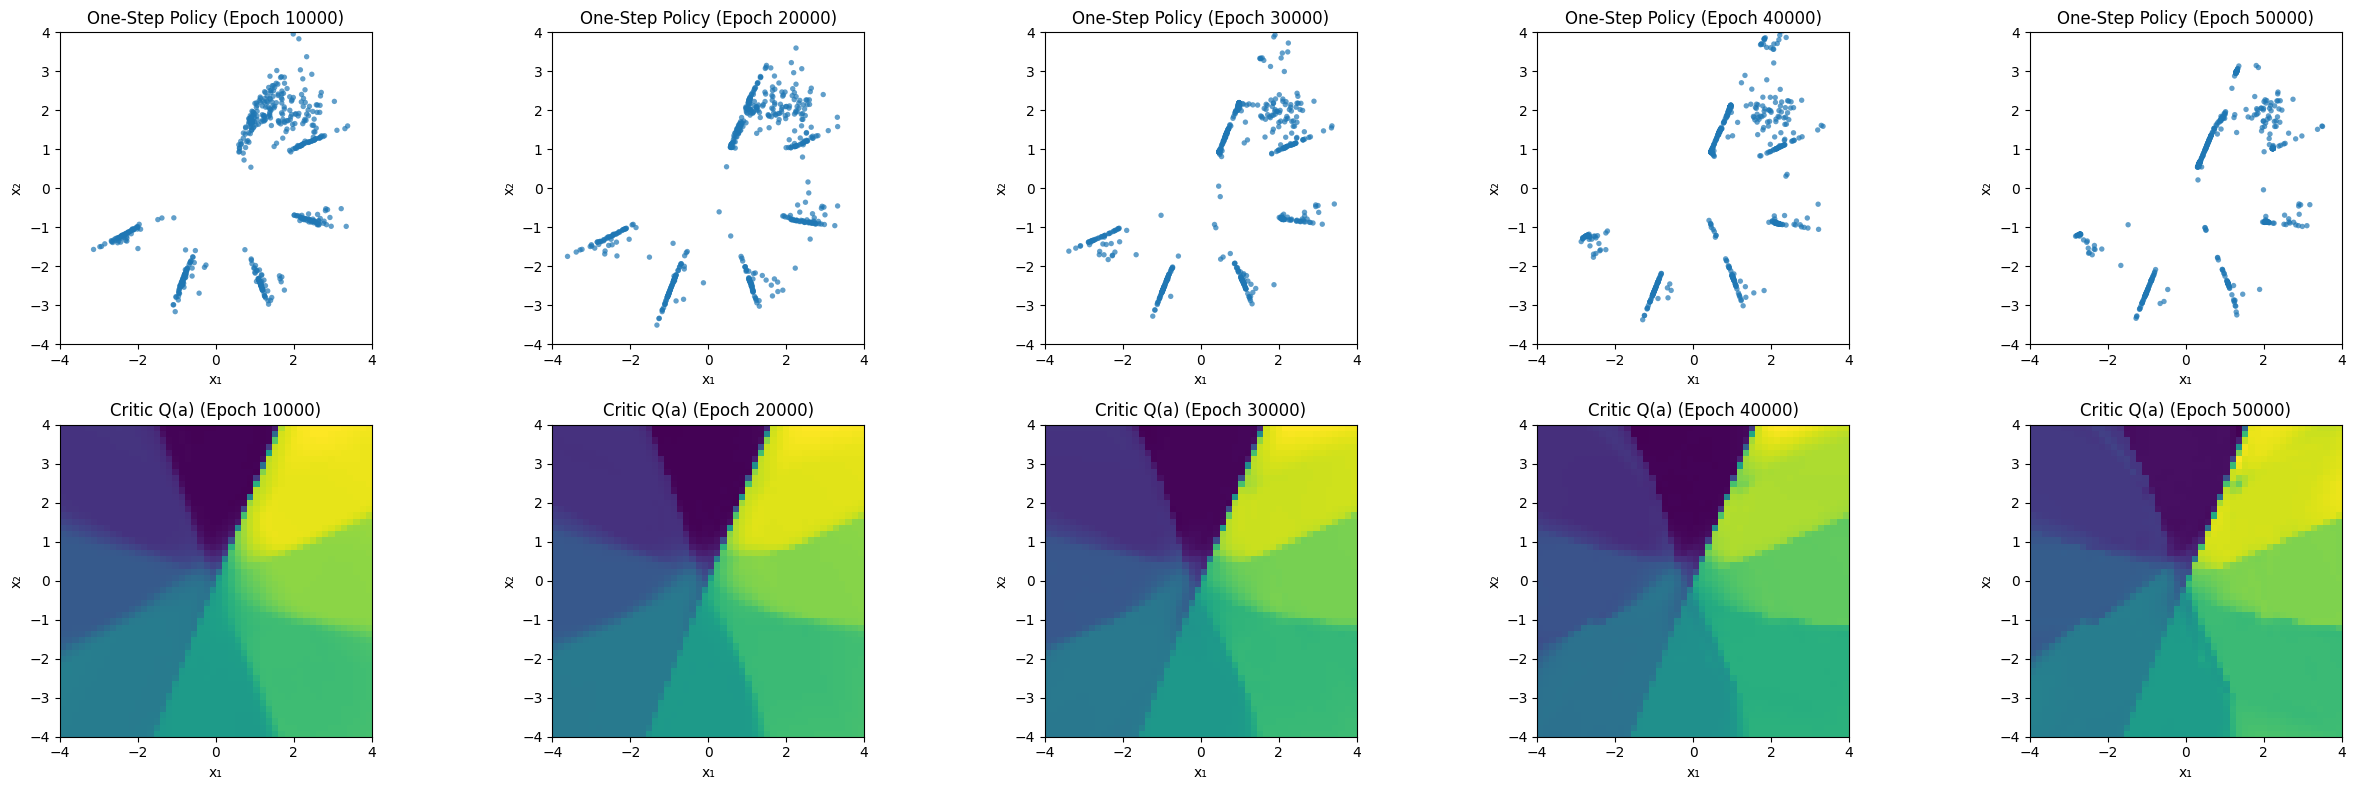

Final Q at policy: 0.8719


In [11]:
# Plot the prediction over the training
plot_step = 10000
alpha=0.1

print("="*60)
print("Training FQL (Policy Distillation) [JAX]")
print("="*60)

fql_flow_params, fql_policy_params, fql_critic_params, fql_history = train_fql(
    x_1_data, rewards_data, 
    epochs=50000,
    lr=3e-4,
    alpha=alpha,  # Weight for Q-maximization
    hidden=512,
    flow_steps=FLOW_STEPS,
    plot_every=plot_step  # Plot every 1000 epochs
)
print(f"Final Q at policy: {fql_history['policy_q'][-1]:.4f}")

In [75]:
# ============================================================================
# Modified training function for inner critic with trajectory tracking
# ============================================================================
def train_fbrac_inner_with_trajectories(x_1_data, rewards_data, fixed_z, plot_epochs, 
                                         epochs=3000, lr=1e-3, alpha=1.0, flow_steps=10, 
                                         hidden=128, use_time_embed=False, time_embed_dim=64, 
                                         max_time_penalty=0.0, time_weight=True,
                                         fbrac_inner_policy_loss_type="vgg_flow_matching"):
    """Train FBRAC inner with trajectory tracking at specified epochs."""
    key = jrandom.PRNGKey(123)
    X1 = jnp.asarray(x_1_data)
    R = jnp.asarray(rewards_data)

    k1, k2, k3, k4 = jrandom.split(key, 4)
    flow_input_dim = 3
    inner_input_dim = 2 + (time_embed_dim if use_time_embed else 1)
    
    flow_params = init_mlp([flow_input_dim, hidden, hidden, 2], k1)
    inner_params = init_mlp([inner_input_dim, hidden, hidden, 1], k2)
    outer_params = init_mlp([2, hidden, hidden, 1], k3)
    
    def _flow_forward(params, x, t):
        return flow_forward(params, x, t)
    
    def _inner_critic_forward(params, x, t):
        if use_time_embed:
            t_embed = fourier_time_embed(t, embed_dim=time_embed_dim)
            xt = jnp.concatenate([x, t_embed], axis=-1)
        else:
            xt = jnp.concatenate([x, t], axis=-1)
        return apply_mlp(params, xt).squeeze(-1)

    flow_opt = optax.adam(lr)
    inner_opt = optax.adam(lr)
    outer_opt = optax.adam(lr)
    flow_opt_state = flow_opt.init(flow_params)
    inner_opt_state = inner_opt.init(inner_params)
    outer_opt_state = outer_opt.init(outer_params)
    
    dt_const = 1.0 / flow_steps
    distillation_batch_scale = 1

    def _integrate_flow_from(flow_params, x, t_start, steps=10):
        """Integrate flow starting at (x, t_start) to t=1 using local _flow_forward."""
        def step_fn(carry, _):
            x_curr, t_curr = carry
            dt = jnp.minimum(1.0 - t_curr, 1.0 / steps)
            v = _flow_forward(flow_params, x_curr, t_curr)
            x_next = x_curr + v * dt
            t_next = t_curr + dt
            x_next = jnp.clip(x_next, DOMAIN_MIN, DOMAIN_MAX)
            return (x_next, t_next), None
        (x_final, _), _ = jax.lax.scan(step_fn, (x, t_start), None, length=steps)
        return x_final
    
    def _integrate_flow(flow_params, z, steps=10):
        """Integrate flow from t=0 to t=1 using local _flow_forward."""
        t0 = jnp.zeros((z.shape[0], 1))
        return _integrate_flow_from(flow_params, z, t0, steps=steps)
    
    def _integrate_flow_full_path(flow_params, z, steps=10):
        """Integrate flow and return full trajectory path with all intermediate points."""
        t0 = jnp.zeros((z.shape[0], 1))
        dt = 1.0 / steps
        
        # Initialize trajectory with starting point
        trajectory = [z]
        x = z
        t_curr = t0
        
        for _ in range(steps):
            v = _flow_forward(flow_params, x, t_curr)
            x = x + v * dt
            t_curr = t_curr + dt
            x = jnp.clip(x, DOMAIN_MIN, DOMAIN_MAX)
            trajectory.append(x)
        
        # Stack all points: shape (steps+1, batch_size, 2)
        return jnp.stack(trajectory, axis=0)

    @partial(jax.jit, static_argnames=("flow_steps", "alpha", "batch_size"))
    def step(state, key, flow_steps, alpha, batch_size):
        flow_params, inner_params, outer_params, flow_opt_state, inner_opt_state, outer_opt_state = state
        key, k_idx, k_noise, k_t, k_pol1, k_pol2, _, _ = jrandom.split(key, 8)
        idx = jrandom.choice(k_idx, X1.shape[0], shape=(batch_size,), replace=False)
        x_1 = X1[idx]
        r = R[idx]

        def outer_loss_fn(params):
            q_pred = critic_forward(params, x_1)
            return jnp.mean((q_pred - r) ** 2)

        outer_loss, outer_grads = jax.value_and_grad(outer_loss_fn)(outer_params)
        outer_updates, outer_opt_state = outer_opt.update(outer_grads, outer_opt_state, outer_params)
        outer_params = optax.apply_updates(outer_params, outer_updates)

        x_0 = jrandom.normal(k_noise, (batch_size*distillation_batch_scale, 2))
        t = jrandom.uniform(k_t, (batch_size*distillation_batch_scale, 1), minval=0.0, maxval=1.0)
        x_t = (1 - t) * x_0 + t * x_1.repeat(distillation_batch_scale, axis=0)
        x_1_pred = _integrate_flow_from(flow_params, x_t, t, steps=flow_steps)

        time_penalty = max_time_penalty * (1.0 - t)
        target_r = jax.lax.stop_gradient(critic_forward(outer_params, x_1_pred)) - time_penalty

        def critic_loss_fn(params):
            v_pred = _inner_critic_forward(params, x_t, t)
            distill_loss = jnp.mean((v_pred - target_r) ** 2)
            return distill_loss, (distill_loss, 0.0)

        (critic_loss, (distill_loss, _)), critic_grads = jax.value_and_grad(critic_loss_fn, has_aux=True)(inner_params)
        inner_updates, inner_opt_state = inner_opt.update(critic_grads, inner_opt_state, inner_params)
        inner_params = optax.apply_updates(inner_params, inner_updates)

        x_0_policy = jrandom.normal(k_pol1, (batch_size, 2))
        t_policy = jrandom.uniform(k_pol2, (batch_size, 1))
        x_t_policy = (1 - t_policy) * x_0_policy + t_policy * x_1
        u_target_policy = x_1 - x_0_policy
        
        if fbrac_inner_policy_loss_type == "vgg_flow_matching":
            def flow_loss_fn(params):
                pred_vel = _flow_forward(params, x_t_policy, t_policy)
                v_base = u_target_policy 
                def value_sum_fn(x_in):
                    return jnp.sum(_inner_critic_forward(inner_params, x_in, t_policy))
                grad_v = jax.grad(value_sum_fn)(x_t_policy)
                grad_v = jax.lax.stop_gradient(grad_v)
                beta = 1/alpha
                if time_weight:
                    v_target = v_base + (1-t_policy)*beta * grad_v
                else:
                    v_target = v_base + beta * grad_v
                matching_loss = jnp.mean((pred_vel - jax.lax.stop_gradient(v_target)) ** 2)
                return matching_loss, (matching_loss, 0.0)

        (flow_loss, (bc_loss, q_val)), flow_grads = jax.value_and_grad(flow_loss_fn, has_aux=True)(flow_params)
        flow_updates, flow_opt_state = flow_opt.update(flow_grads, flow_opt_state, flow_params)
        flow_params = optax.apply_updates(flow_params, flow_updates)

        logs = (bc_loss, distill_loss, q_val, flow_loss, outer_loss)
        new_state = (flow_params, inner_params, outer_params, flow_opt_state, inner_opt_state, outer_opt_state)
        return new_state, (key, logs)

    history = {
        'flow_bc_loss': [], 'critic_distill': [],
        'flow_q_loss': [], 'flow_total': [], 'outer_loss': []
    }
    
    trajectories = []
    
    state = (flow_params, inner_params, outer_params, flow_opt_state, inner_opt_state, outer_opt_state)
    next_plot_idx = 0
    
    # Capture initial trajectory (epoch 0) if needed
    if next_plot_idx < len(plot_epochs) and plot_epochs[next_plot_idx] == 0:
        flow_params_curr, _, _, _, _, _ = state
        trajectory = np.array(_integrate_flow_full_path(flow_params_curr, fixed_z, steps=flow_steps))
        # trajectory shape: (steps+1, n_trajectories, 2)
        trajectories.append(trajectory)
        next_plot_idx += 1
    
    for epoch in trange(epochs, desc="fbrac_inner (with trajectory tracking)"):
        state, (key, logs) = step(state, key, flow_steps, alpha, batch_size)
        bc_loss, distill_loss, q_val, flow_loss, outer_loss = logs
        history['flow_bc_loss'].append(float(bc_loss))
        history['critic_distill'].append(float(distill_loss))
        history['flow_q_loss'].append(float(q_val))
        history['flow_total'].append(float(flow_loss))
        history['outer_loss'].append(float(outer_loss))
        
        # Track trajectory at specified epochs (epoch+1 because we've completed that many steps)
        current_epoch = epoch + 1
        if next_plot_idx < len(plot_epochs) and current_epoch == plot_epochs[next_plot_idx]:
            flow_params_curr, _, _, _, _, _ = state
            trajectory = np.array(_integrate_flow_full_path(flow_params_curr, fixed_z, steps=flow_steps))
            trajectories.append(trajectory)
            next_plot_idx += 1

    # Capture final trajectory if needed (after all training)
    flow_params, inner_params, _, _, _, _ = state
    if next_plot_idx < len(plot_epochs) and plot_epochs[next_plot_idx] == epochs:
        trajectory = np.array(_integrate_flow_full_path(flow_params, fixed_z, steps=flow_steps))
        trajectories.append(trajectory)
        next_plot_idx += 1
    
    return flow_params, inner_params, history, trajectories

# ============================================================================
# Modified training function for outer critic with trajectory tracking
# ============================================================================
def train_fbrac_with_trajectories(x_1_data, rewards_data, fixed_z, plot_epochs,
                                   epochs=3000, lr=1e-3, alpha=1.0, flow_steps=10, hidden=128):
    """Train FBRAC outer with trajectory tracking at specified epochs."""
    key = jrandom.PRNGKey(456)
    X1 = jnp.asarray(x_1_data)
    R = jnp.asarray(rewards_data)

    k1, k2 = jrandom.split(key, 2)
    flow_params = init_mlp([3, hidden, hidden, 2], k1)
    critic_params = init_mlp([2, hidden, hidden, 1], k2)

    flow_opt = optax.adam(lr)
    critic_opt = optax.adam(lr)
    flow_opt_state = flow_opt.init(flow_params)
    critic_opt_state = critic_opt.init(critic_params)

    def integrate_for_grad(flow_p, x_start, n_steps):
        """Differentiable flow integration."""
        dt = 1.0 / n_steps
        x = x_start
        t_curr = jnp.zeros((x.shape[0], 1))
        for _ in range(n_steps):
            v = flow_forward(flow_p, x, t_curr)
            x = x + v * dt
            t_curr = t_curr + dt
        return jnp.clip(x, DOMAIN_MIN, DOMAIN_MAX)
    
    def integrate_flow_full_path(flow_params, z, steps=10):
        """Integrate flow and return full trajectory path with all intermediate points."""
        t0 = jnp.zeros((z.shape[0], 1))
        dt = 1.0 / steps
        
        # Initialize trajectory with starting point
        trajectory = [z]
        x = z
        t_curr = t0
        
        for _ in range(steps):
            v = flow_forward(flow_params, x, t_curr)
            x = x + v * dt
            t_curr = t_curr + dt
            x = jnp.clip(x, DOMAIN_MIN, DOMAIN_MAX)
            trajectory.append(x)
        
        # Stack all points: shape (steps+1, batch_size, 2)
        return jnp.stack(trajectory, axis=0)

    @partial(jax.jit, static_argnames=("flow_steps", "alpha", "batch_size"))
    def step(state, key, flow_steps, alpha, batch_size):
        flow_params, critic_params, flow_opt_state, critic_opt_state = state
        key, k_idx, k_z, k_t, k_pol = jrandom.split(key, 5)
        idx = jrandom.choice(k_idx, X1.shape[0], shape=(batch_size,), replace=False)
        x_1 = X1[idx]
        r = R[idx]

        def critic_loss_fn(params):
            q_pred = critic_forward(params, x_1)
            return jnp.mean((q_pred - r) ** 2)

        critic_loss, critic_grads = jax.value_and_grad(critic_loss_fn)(critic_params)
        critic_updates, critic_opt_state = critic_opt.update(critic_grads, critic_opt_state, critic_params)
        critic_params = optax.apply_updates(critic_params, critic_updates)

        # --- Flow Update: BC + Q-maximization ---
        z = jrandom.normal(k_z, (batch_size, 2))
        t = jrandom.uniform(k_t, (batch_size, 1))
        x_t = (1 - t) * z + t * x_1
        u_target = x_1 - z  # Flow matching target

        def flow_loss_fn(params):
            # 1. BC Loss (flow matching)
            v_pred = flow_forward(params, x_t, t)
            bc_loss = jnp.mean((v_pred - u_target) ** 2)

            # 2. Q-Maximization: integrate flow and maximize Q at the end
            # Sample fresh noise for policy evaluation
            z_policy = jrandom.normal(k_pol, (batch_size, 2))
            
            # Generate actions using current flow parameters (differentiable)
            clean_actions = integrate_for_grad(params, z_policy, flow_steps)
            
            # Maximize Q(clean_actions) - use stop_gradient on critic
            q_at_actions = critic_forward(jax.lax.stop_gradient(critic_params), clean_actions)
            q_loss = -jnp.mean(q_at_actions)

            return alpha * bc_loss + q_loss, (bc_loss, jnp.mean(q_at_actions))

        (flow_loss, (bc_loss, q_val)), flow_grads = jax.value_and_grad(flow_loss_fn, has_aux=True)(flow_params)
        flow_updates, flow_opt_state = flow_opt.update(flow_grads, flow_opt_state, flow_params)
        flow_params = optax.apply_updates(flow_params, flow_updates)

        logs = (q_val, flow_loss, critic_loss)
        new_state = (flow_params, critic_params, flow_opt_state, critic_opt_state)
        return new_state, (key, logs)

    history = {'flow_q_loss': [], 'flow_total': [], 'critic_loss': []}
    trajectories = []
    
    state = (flow_params, critic_params, flow_opt_state, critic_opt_state)
    next_plot_idx = 0
    
    # Capture initial trajectory (epoch 0) if needed
    if next_plot_idx < len(plot_epochs) and plot_epochs[next_plot_idx] == 0:
        flow_params_curr, _, _, _ = state
        trajectory = np.array(integrate_flow_full_path(flow_params_curr, fixed_z, steps=flow_steps))
        # trajectory shape: (steps+1, n_trajectories, 2)
        trajectories.append(trajectory)
        next_plot_idx += 1
    
    for epoch in trange(epochs, desc="fbrac_outer (with trajectory tracking)"):
        state, (key, logs) = step(state, key, flow_steps, alpha, batch_size)
        q_val, flow_loss, critic_loss = logs
        history['flow_q_loss'].append(float(q_val))
        history['flow_total'].append(float(flow_loss))
        history['critic_loss'].append(float(critic_loss))
        
        # Track trajectory at specified epochs (epoch+1 because we've completed that many steps)
        current_epoch = epoch + 1
        if next_plot_idx < len(plot_epochs) and current_epoch == plot_epochs[next_plot_idx]:
            flow_params_curr, _, _, _ = state
            trajectory = np.array(integrate_flow_full_path(flow_params_curr, fixed_z, steps=flow_steps))
            trajectories.append(trajectory)
            next_plot_idx += 1

    # Capture final trajectory if needed (after all training)
    flow_params, critic_params, _, _ = state
    if next_plot_idx < len(plot_epochs) and plot_epochs[next_plot_idx] == epochs:
        trajectory = np.array(integrate_flow_full_path(flow_params, fixed_z, steps=flow_steps))
        trajectories.append(trajectory)
        next_plot_idx += 1
    
    return flow_params, critic_params, history, trajectories

TRAJECTORY EVOLUTION COMPARISON
Training both methods and tracking trajectories...
Plot steps: 300 epochs
Total epochs: 3000
Will track trajectories at epochs: [0, 1000, 2000, 3000]
Using 30 fixed initial noise values

Training FBRAC Inner (with trajectory tracking)...


fbrac_inner (with trajectory tracking):   0%|          | 0/3000 [00:00<?, ?it/s]

fbrac_inner (with trajectory tracking): 100%|██████████| 3000/3000 [00:11<00:00, 262.35it/s]



Training FBRAC Outer (with trajectory tracking)...


fbrac_outer (with trajectory tracking): 100%|██████████| 3000/3000 [00:15<00:00, 192.27it/s]



Tracked 4 epochs for inner critic
Tracked 4 epochs for outer critic

Creating trajectory evolution visualization...
Plotting 4 epochs with 30 trajectories each


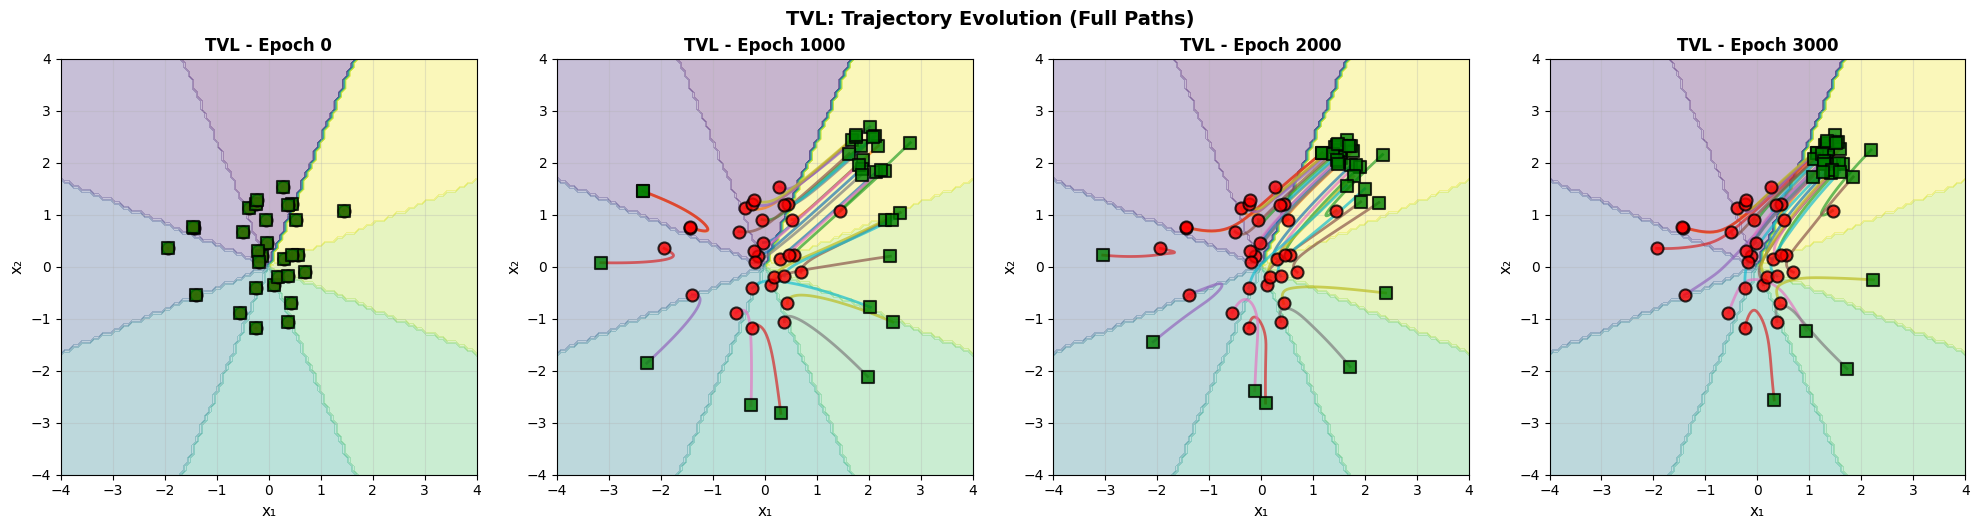

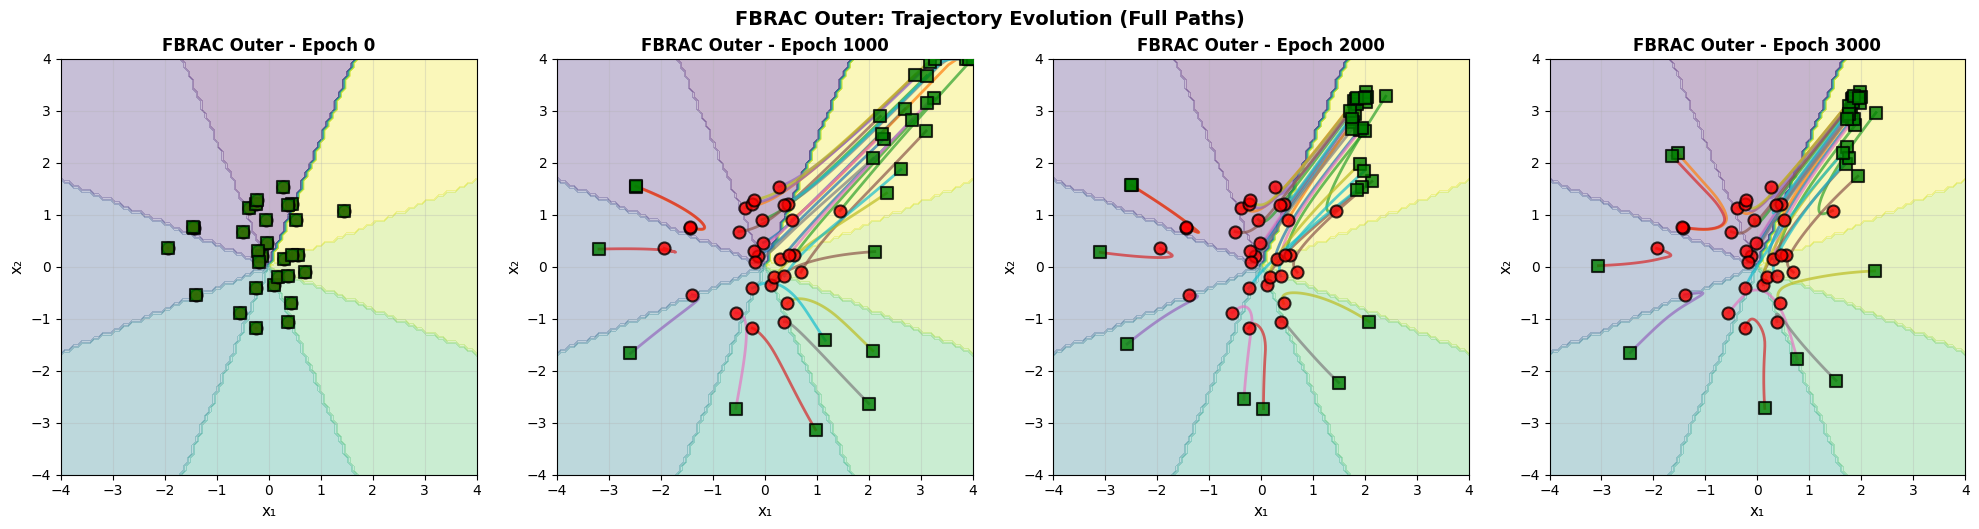

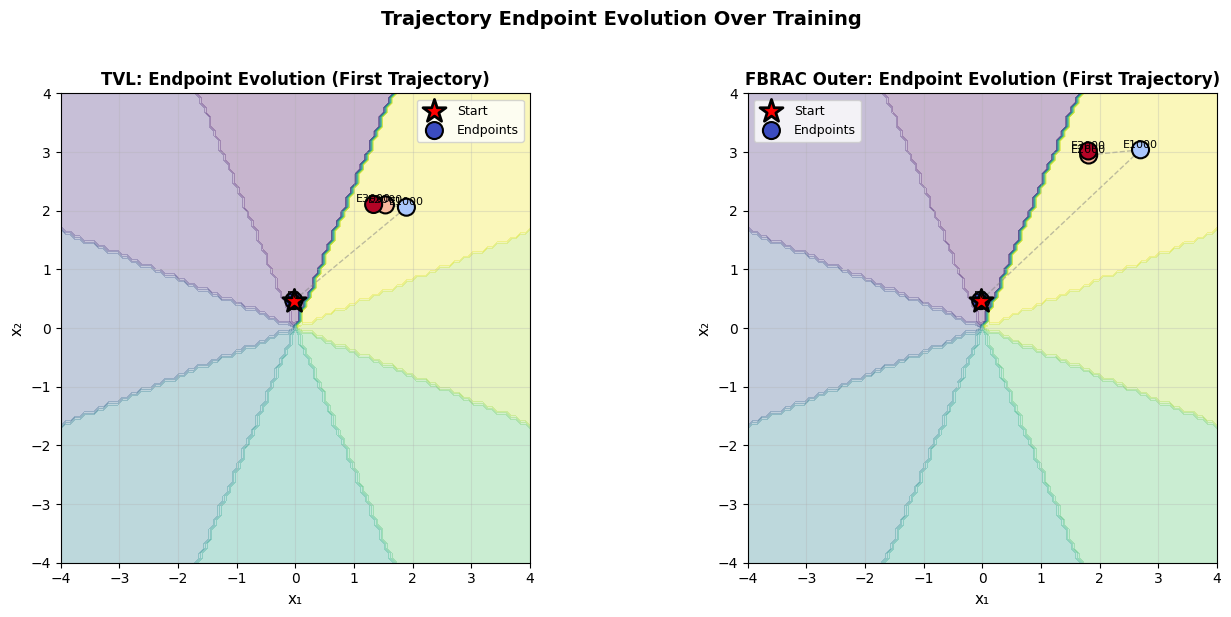


TRAJECTORY EVOLUTION SUMMARY
Initial noise position (first trajectory): (-0.0283, 0.4671)

FBRAC Inner final position (first trajectory): (1.3320, 2.1054)
FBRAC Outer final position (first trajectory): (1.8059, 3.0179)

FBRAC Inner reward progression (avg across 30 trajectories):
  Epoch    0: 0.3952
  Epoch 1000: 0.8286
  Epoch 2000: 0.9143
  Epoch 3000: 0.9619

FBRAC Outer reward progression (avg across 30 trajectories):
  Epoch    0: 0.3952
  Epoch 1000: 0.8381
  Epoch 2000: 0.8524
  Epoch 3000: 0.8619

Final reward comparison:
  FBRAC Inner: 0.9619
  FBRAC Outer: 0.8619


In [103]:
# ============================================================================
# TRAJECTORY EVOLUTION COMPARISON: Inner vs Outer Critic
# ============================================================================
# Compare how trajectories generated by the policy change over training time
# Using a fixed initial noise, track trajectory evolution every 300 epochs

print("="*60)
print("TRAJECTORY EVOLUTION COMPARISON")
print("="*60)
print("Training both methods and tracking trajectories...")
print(f"Plot steps: 300 epochs")
print(f"Total epochs: 3000")
print("="*60)

# Use the same batch_size as the rest of the notebook
# batch_size is already defined globally (1024)

# Fixed initial noise for consistent comparison
FIXED_NOISE_KEY = jrandom.PRNGKey(42)
n_trajectories_eval = 30  # Number of different initial noise values to track
fixed_z = jrandom.normal(FIXED_NOISE_KEY, (n_trajectories_eval, 2))

# Parameters
TOTAL_EPOCHS = 3000
PLOT_STEPS = 1000
plot_epochs = list(range(0, TOTAL_EPOCHS + 1, PLOT_STEPS))
if plot_epochs[-1] != TOTAL_EPOCHS:
    plot_epochs.append(TOTAL_EPOCHS)

print(f"Will track trajectories at epochs: {plot_epochs}")
print(f"Using {n_trajectories_eval} fixed initial noise values")

# Storage for trajectories
trajectories_inner = []
trajectories_outer = []
epochs_tracked = []

# ============================================================================
# Train both methods with trajectory tracking
# ============================================================================
alpha=0.3

print("\nTraining FBRAC Inner (with trajectory tracking)...")
fbrac_inner_flow_params, fbrac_inner_critic_params, fbrac_inner_history, trajectories_inner = train_fbrac_inner_with_trajectories(
    x_1_data, rewards_data, fixed_z, plot_epochs,
    epochs=TOTAL_EPOCHS,
    lr=3e-4,
    alpha=alpha,
    flow_steps=FLOW_STEPS,
    use_time_embed=True,
    time_embed_dim=16,
    max_time_penalty=0.0,
    time_weight=False,
    fbrac_inner_policy_loss_type="vgg_flow_matching"
)

print("\nTraining FBRAC Outer (with trajectory tracking)...")
fbrac_outer_flow_params, fbrac_outer_critic_params, fbrac_outer_history, trajectories_outer = train_fbrac_with_trajectories(
    x_1_data, rewards_data, fixed_z, plot_epochs,
    epochs=TOTAL_EPOCHS,
    lr=3e-4,
    alpha=alpha,
    flow_steps=FLOW_STEPS
)

print(f"\nTracked {len(trajectories_inner)} epochs for inner critic")
print(f"Tracked {len(trajectories_outer)} epochs for outer critic")

# ============================================================================
# Visualize trajectory evolution
# ============================================================================
print("\nCreating trajectory evolution visualization...")

# Safety check and setup
n_epochs_tracked = min(len(trajectories_inner), len(trajectories_outer), len(plot_epochs))
print(f"Plotting {n_epochs_tracked} epochs with {n_trajectories_eval} trajectories each")

# Plot reward landscape as background
resolution = 100
x = np.linspace(DOMAIN_MIN, DOMAIN_MAX, resolution)
y = np.linspace(DOMAIN_MIN, DOMAIN_MAX, resolution)
X, Y = np.meshgrid(x, y)
positions = np.stack([X.ravel(), Y.ravel()], axis=-1)
rewards_grid = np.array(reward_fn_vec(jnp.asarray(positions))).reshape(resolution, resolution)

# Initial positions for all trajectories
initial_positions = np.array(fixed_z)  # Shape: (n_trajectories_eval, 2)

# ============================================================================
# FBRAC Inner: Separate figure with full trajectory paths
# ============================================================================
n_cols = min(4, n_epochs_tracked)  # Max 4 columns for readability
n_rows = (n_epochs_tracked + n_cols - 1) // n_cols
fig_inner, axes_inner = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 5*n_rows))
if n_epochs_tracked == 1:
    axes_inner = np.array([axes_inner])
axes_inner = axes_inner.flatten()

for i in range(n_epochs_tracked):
    epoch = plot_epochs[i]
    ax = axes_inner[i]
    ax.contourf(X, Y, rewards_grid, levels=20, cmap='viridis', alpha=0.3, zorder=0)
    
    # Get full trajectory path for this epoch
    # traj_inner shape: (steps+1, n_trajectories_eval, 2)
    traj_full = trajectories_inner[i]  # Shape: (steps+1, n_trajectories_eval, 2)
    colors = plt.cm.tab10(np.linspace(0, 1, n_trajectories_eval))
    
    # Plot each trajectory path
    for traj_idx in range(n_trajectories_eval):
        # Extract path for this trajectory: (steps+1, 2)
        path = traj_full[:, traj_idx, :]  # Shape: (steps+1, 2)
        initial_pos = initial_positions[traj_idx]
        
        # Plot the actual trajectory path
        ax.plot(path[:, 0], path[:, 1], '-', linewidth=2, 
               color=colors[traj_idx], alpha=0.7, zorder=2)
        
        # Mark start and end points
        ax.scatter(initial_pos[0], initial_pos[1], s=75, c='red', marker='o', 
                  edgecolors='black', linewidths=1.5, zorder=3, alpha=0.8)
        ax.scatter(path[-1, 0], path[-1, 1], s=75, c='green', marker='s', 
                  edgecolors='black', linewidths=1.5, zorder=3, alpha=0.8)
    
    ax.set_title(f'TVL - Epoch {epoch}', fontsize=12, fontweight='bold')
    ax.set_xlabel('x₁', fontsize=11)
    ax.set_ylabel('x₂', fontsize=11)
    ax.set_xlim(DOMAIN_MIN, DOMAIN_MAX)
    ax.set_ylim(DOMAIN_MIN, DOMAIN_MAX)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

# Hide unused subplots
for i in range(n_epochs_tracked, len(axes_inner)):
    axes_inner[i].axis('off')

plt.suptitle('TVL: Trajectory Evolution (Full Paths)', 
             fontsize=14, fontweight='bold', y=1.0)
plt.tight_layout()
plt.show()

# ============================================================================
# FBRAC Outer: Separate figure with full trajectory paths
# ============================================================================
fig_outer, axes_outer = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 5*n_rows))
if n_epochs_tracked == 1:
    axes_outer = np.array([axes_outer])
axes_outer = axes_outer.flatten()

for i in range(n_epochs_tracked):
    epoch = plot_epochs[i]
    ax = axes_outer[i]
    ax.contourf(X, Y, rewards_grid, levels=20, cmap='viridis', alpha=0.3, zorder=0)
    
    # Get full trajectory path for this epoch
    # traj_outer shape: (steps+1, n_trajectories_eval, 2)
    traj_full = trajectories_outer[i]  # Shape: (steps+1, n_trajectories_eval, 2)
    colors = plt.cm.tab10(np.linspace(0, 1, n_trajectories_eval))
    
    # Plot each trajectory path
    for traj_idx in range(n_trajectories_eval):
        # Extract path for this trajectory: (steps+1, 2)
        path = traj_full[:, traj_idx, :]  # Shape: (steps+1, 2)
        initial_pos = initial_positions[traj_idx]
        
        # Plot the actual trajectory path
        ax.plot(path[:, 0], path[:, 1], '-', linewidth=2, 
               color=colors[traj_idx], alpha=0.7, zorder=2)
        
        # Mark start and end points
        ax.scatter(initial_pos[0], initial_pos[1], s=75, c='red', marker='o', 
                  edgecolors='black', linewidths=1.5, zorder=3, alpha=0.8)
        ax.scatter(path[-1, 0], path[-1, 1], s=75, c='green', marker='s', 
                  edgecolors='black', linewidths=1.5, zorder=3, alpha=0.8)
    
    ax.set_title(f'FBRAC Outer - Epoch {epoch}', fontsize=12, fontweight='bold')
    ax.set_xlabel('x₁', fontsize=11)
    ax.set_ylabel('x₂', fontsize=11)
    ax.set_xlim(DOMAIN_MIN, DOMAIN_MAX)
    ax.set_ylim(DOMAIN_MIN, DOMAIN_MAX)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

# Hide unused subplots
for i in range(n_epochs_tracked, len(axes_outer)):
    axes_outer[i].axis('off')

plt.suptitle('FBRAC Outer: Trajectory Evolution (Full Paths)', 
             fontsize=14, fontweight='bold', y=1.0)
plt.tight_layout()
plt.show()

# ============================================================================
# Additional visualization: Trajectory endpoints over time (first trajectory only)
# ============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Extract endpoints for the first trajectory only (for cleaner visualization)
endpoints_inner = np.array([traj[-1, 0, :] for traj in trajectories_inner])  # Shape: (n_epochs, 2)
endpoints_outer = np.array([traj[-1, 0, :] for traj in trajectories_outer])  # Shape: (n_epochs, 2)
initial_pos_first = initial_positions[0]  # First trajectory's initial position

# Inner critic
ax1.contourf(X, Y, rewards_grid, levels=20, cmap='viridis', alpha=0.3, zorder=0)
ax1.scatter(initial_pos_first[0], initial_pos_first[1], s=300, c='red', marker='*', 
           edgecolors='black', linewidths=2, label='Start', zorder=3)
ax1.scatter(endpoints_inner[:, 0], endpoints_inner[:, 1], 
           c=plot_epochs[:n_epochs_tracked], cmap='coolwarm', s=150, edgecolors='black', 
           linewidths=1.5, zorder=2, label='Endpoints')
ax1.plot(endpoints_inner[:, 0], endpoints_inner[:, 1], '--', color='gray', 
        alpha=0.5, linewidth=1, zorder=1)
for i, epoch in enumerate(plot_epochs[:n_epochs_tracked]):
    ax1.annotate(f'E{epoch}', (endpoints_inner[i, 0], endpoints_inner[i, 1]),
                fontsize=8, ha='center', va='bottom')
ax1.set_title('TVL: Endpoint Evolution (First Trajectory)', fontsize=12, fontweight='bold')
ax1.set_xlabel('x₁', fontsize=11)
ax1.set_ylabel('x₂', fontsize=11)
ax1.set_xlim(DOMAIN_MIN, DOMAIN_MAX)
ax1.set_ylim(DOMAIN_MIN, DOMAIN_MAX)
ax1.set_aspect('equal')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=9)

# Outer critic
ax2.contourf(X, Y, rewards_grid, levels=20, cmap='viridis', alpha=0.3, zorder=0)
ax2.scatter(initial_pos_first[0], initial_pos_first[1], s=300, c='red', marker='*', 
           edgecolors='black', linewidths=2, label='Start', zorder=3)
ax2.scatter(endpoints_outer[:, 0], endpoints_outer[:, 1], 
           c=plot_epochs[:n_epochs_tracked], cmap='coolwarm', s=150, edgecolors='black', 
           linewidths=1.5, zorder=2, label='Endpoints')
ax2.plot(endpoints_outer[:, 0], endpoints_outer[:, 1], '--', color='gray', 
        alpha=0.5, linewidth=1, zorder=1)
for i, epoch in enumerate(plot_epochs[:n_epochs_tracked]):
    ax2.annotate(f'E{epoch}', (endpoints_outer[i, 0], endpoints_outer[i, 1]),
                fontsize=8, ha='center', va='bottom')
ax2.set_title('FBRAC Outer: Endpoint Evolution (First Trajectory)', fontsize=12, fontweight='bold')
ax2.set_xlabel('x₁', fontsize=11)
ax2.set_ylabel('x₂', fontsize=11)
ax2.set_xlim(DOMAIN_MIN, DOMAIN_MAX)
ax2.set_ylim(DOMAIN_MIN, DOMAIN_MAX)
ax2.set_aspect('equal')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=9)

plt.suptitle('Trajectory Endpoint Evolution Over Training', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ============================================================================
# Summary statistics
# ============================================================================
print("\n" + "="*60)
print("TRAJECTORY EVOLUTION SUMMARY")
print("="*60)
print(f"Initial noise position (first trajectory): ({initial_pos_first[0]:.4f}, {initial_pos_first[1]:.4f})")
print(f"\nFBRAC Inner final position (first trajectory): ({endpoints_inner[-1, 0]:.4f}, {endpoints_inner[-1, 1]:.4f})")
print(f"FBRAC Outer final position (first trajectory): ({endpoints_outer[-1, 0]:.4f}, {endpoints_outer[-1, 1]:.4f})")

# Calculate rewards at endpoints (average across all trajectories)
rewards_inner = []
rewards_outer = []
for i in range(n_epochs_tracked):
    # Get endpoints for all trajectories at this epoch
    traj_inner_epoch = trajectories_inner[i]  # Shape: (steps+1, n_trajectories_eval, 2)
    traj_outer_epoch = trajectories_outer[i]  # Shape: (steps+1, n_trajectories_eval, 2)
    
    # Extract final endpoints: (n_trajectories_eval, 2)
    endpoints_inner_epoch = traj_inner_epoch[-1, :, :]
    endpoints_outer_epoch = traj_outer_epoch[-1, :, :]
    
    # Calculate average reward across all trajectories
    rewards_inner_epoch = np.array(reward_fn_vec(jnp.asarray(endpoints_inner_epoch)))
    rewards_outer_epoch = np.array(reward_fn_vec(jnp.asarray(endpoints_outer_epoch)))
    
    rewards_inner.append(np.mean(rewards_inner_epoch))
    rewards_outer.append(np.mean(rewards_outer_epoch))

print(f"\nFBRAC Inner reward progression (avg across {n_trajectories_eval} trajectories):")
for i, epoch in enumerate(plot_epochs[:n_epochs_tracked]):
    print(f"  Epoch {epoch:4d}: {rewards_inner[i]:.4f}")

print(f"\nFBRAC Outer reward progression (avg across {n_trajectories_eval} trajectories):")
for i, epoch in enumerate(plot_epochs[:n_epochs_tracked]):
    print(f"  Epoch {epoch:4d}: {rewards_outer[i]:.4f}")

print(f"\nFinal reward comparison:")
print(f"  FBRAC Inner: {rewards_inner[-1]:.4f}")
print(f"  FBRAC Outer: {rewards_outer[-1]:.4f}")
print("="*60)

In [80]:
# Trajectory plotting with step markers colored by final Q
# Options: flow models ('fbrac_inner', 'fbrac_outer', 'fql_flow') and one-step ('fql_onestep')
model = 'fbrac_inner'
model_cfg = {
    'fbrac_outer': ('flow', fbrac_outer_flow_params, 'FBRAC Outer Flow'),
    'fbrac_inner': ('flow', fbrac_inner_flow_params, 'FBRAC Inner Flow'),
    'fql_flow': ('flow', fql_flow_params, 'FQL Flow Teacher'),
    'fql_onestep': ('onestep', fql_policy_params, 'FQL One-Step Policy'),
}
if model not in model_cfg:
    raise ValueError(f"model must be one of {list(model_cfg.keys())}")

model_type, params, model_label = model_cfg[model]

n_traj = 50         # number of trajectories (small for clarity)
steps = 10         # integration steps per trajectory (flow models only)
seed = 0           # RNG seed for reproducibility

key = jrandom.PRNGKey(seed)
z0 = jrandom.normal(key, (n_traj, 2))

if model_type == 'flow':
    dt = 1.0 / steps
    x = z0
    t = jnp.zeros((n_traj, 1))
    traj = []
    for i in range(steps + 1):
        traj.append(np.array(x))
        if i == steps:
            break
        v = flow_forward(params, x, t)
        x = x + v * dt
        x = jnp.clip(x, DOMAIN_MIN, DOMAIN_MAX)
        t = t + dt
    traj = np.stack(traj, axis=0)  # (steps+1, n_traj, 2)
    x_final = traj[-1]
else:  # one-step policy
    x_final = np.array(onestep_forward(params, z0))
    traj = np.stack([np.array(z0), x_final], axis=0)  # (2, n_traj, 2)

# Final Q for coloring
if model == 'fbrac_inner':
    x_final_jax = jnp.asarray(x_final)
    t_final = jnp.ones((n_traj, 1))
    t_embed = fourier_time_embed(t_final, embed_dim=16)
    xt = jnp.concatenate([x_final_jax, t_embed], axis=-1)
    q_final = np.array(apply_mlp(fbrac_inner_critic_params, xt).squeeze(-1))
elif model == 'fbrac_outer':
    q_final = np.array(critic_forward(fbrac_outer_critic_params, jnp.asarray(x_final)))
elif model == 'fql_flow':
    q_final = np.array(critic_forward(fql_critic_params, jnp.asarray(x_final)))
elif model == 'fql_onestep':
    q_final = np.array(critic_forward(fql_critic_params, jnp.asarray(x_final)))
else:
    raise ValueError(f"Unknown model for critic lookup: {model}")

vmin = np.percentile(q_final, 5)
vmax = np.percentile(q_final, 95)
if vmin == vmax:
    vmax = vmin + 1e-3
norm = plt.Normalize(vmin=vmin, vmax=vmax)
cmap = plt.cm.viridis
colors = cmap(norm(q_final))

fig, ax = plt.subplots(figsize=(8, 7))
for i in range(n_traj):
    path = traj[:, i, :]
    ax.plot(path[:, 0], path[:, 1], color=colors[i], alpha=0.9, linewidth=1.6)
    # mark every step along the trajectory
    ax.scatter(path[:, 0], path[:, 1], color=colors[i], s=16, alpha=0.9)
    ax.scatter(path[0, 0], path[0, 1], color='blue', s=35, marker='o', label='start' if i == 0 else None)
    ax.scatter(path[-1, 0], path[-1, 1], color='red', s=45, marker='x', label='end' if i == 0 else None)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label='Final Q(x_end)')

ax.set_title(f"Stepwise sampling trajectories colored by final Q ({model_label})")
ax.set_xlabel('x₁')
ax.set_ylabel('x₂')
ax.set_xlim(DOMAIN_MIN, DOMAIN_MAX)
ax.set_ylim(DOMAIN_MIN, DOMAIN_MAX)
ax.set_aspect('equal')
ax.legend(loc='upper right')
plt.show()

NameError: name 'fql_flow_params' is not defined

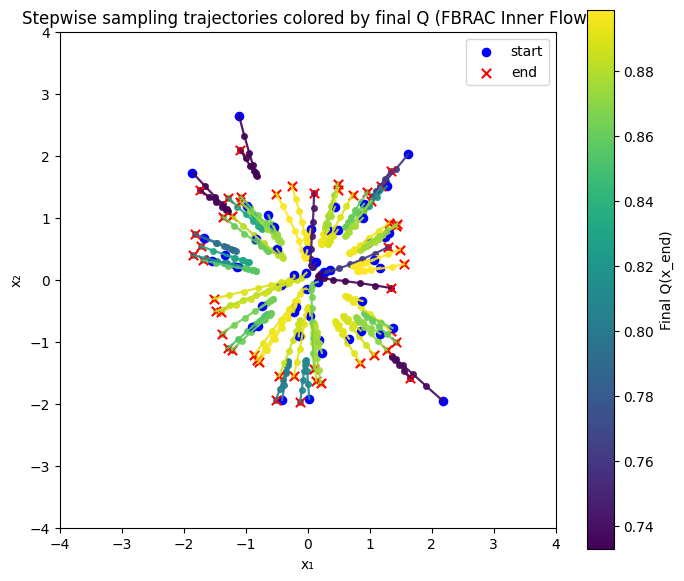

In [82]:
# Trajectory plotting with step markers colored by final Q
# Options: flow models ('fbrac_inner', 'fbrac_outer', 'fql_flow') and one-step ('fql_onestep')
model = 'fbrac_inner'
model_cfg = {
    'fbrac_outer': ('flow', fbrac_outer_flow_params, 'FBRAC Outer Flow'),
    'fbrac_inner': ('flow', fbrac_inner_flow_params, 'FBRAC Inner Flow'),
    'fql_flow': ('flow', fql_flow_params, 'FQL Flow Teacher'),
    'fql_onestep': ('onestep', fql_policy_params, 'FQL One-Step Policy'),
}
if model not in model_cfg:
    raise ValueError(f"model must be one of {list(model_cfg.keys())}")

model_type, params, model_label = model_cfg[model]

n_traj = 50         # number of trajectories (small for clarity)
steps = 10         # integration steps per trajectory (flow models only)
seed = 0           # RNG seed for reproducibility

key = jrandom.PRNGKey(seed)
z0 = jrandom.normal(key, (n_traj, 2))

if model_type == 'flow':
    dt = 1.0 / steps
    x = z0
    t = jnp.zeros((n_traj, 1))
    traj = []
    for i in range(steps + 1):
        traj.append(np.array(x))
        if i == steps:
            break
        v = flow_forward(params, x, t)
        x = x + v * dt
        x = jnp.clip(x, DOMAIN_MIN, DOMAIN_MAX)
        t = t + dt
    traj = np.stack(traj, axis=0)  # (steps+1, n_traj, 2)
    x_final = traj[-1]
else:  # one-step policy
    x_final = np.array(onestep_forward(params, z0))
    traj = np.stack([np.array(z0), x_final], axis=0)  # (2, n_traj, 2)

# Final Q for coloring
if model == 'fbrac_inner':
    x_final_jax = jnp.asarray(x_final)
    t_final = jnp.ones((n_traj, 1))
    t_embed = fourier_time_embed(t_final, embed_dim=16)
    xt = jnp.concatenate([x_final_jax, t_embed], axis=-1)
    q_final = np.array(apply_mlp(fbrac_inner_critic_params, xt).squeeze(-1))
elif model == 'fbrac_outer':
    q_final = np.array(critic_forward(fbrac_outer_critic_params, jnp.asarray(x_final)))
elif model == 'fql_flow':
    q_final = np.array(critic_forward(fql_critic_params, jnp.asarray(x_final)))
elif model == 'fql_onestep':
    q_final = np.array(critic_forward(fql_critic_params, jnp.asarray(x_final)))
else:
    raise ValueError(f"Unknown model for critic lookup: {model}")

vmin = np.percentile(q_final, 5)
vmax = np.percentile(q_final, 95)
if vmin == vmax:
    vmax = vmin + 1e-3
norm = plt.Normalize(vmin=vmin, vmax=vmax)
cmap = plt.cm.viridis
colors = cmap(norm(q_final))

fig, ax = plt.subplots(figsize=(8, 7))
for i in range(n_traj):
    path = traj[:, i, :]
    ax.plot(path[:, 0], path[:, 1], color=colors[i], alpha=0.9, linewidth=1.6)
    # mark every step along the trajectory
    ax.scatter(path[:, 0], path[:, 1], color=colors[i], s=16, alpha=0.9)
    ax.scatter(path[0, 0], path[0, 1], color='blue', s=35, marker='o', label='start' if i == 0 else None)
    ax.scatter(path[-1, 0], path[-1, 1], color='red', s=45, marker='x', label='end' if i == 0 else None)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label='Final Q(x_end)')

ax.set_title(f"Stepwise sampling trajectories colored by final Q ({model_label})")
ax.set_xlabel('x₁')
ax.set_ylabel('x₂')
ax.set_xlim(DOMAIN_MIN, DOMAIN_MAX)
ax.set_ylim(DOMAIN_MIN, DOMAIN_MAX)
ax.set_aspect('equal')
ax.legend(loc='upper right')
plt.show()

Training FBRAC (Flow + Outer Q, no distillation) [JAX]


FBRAC (JAX):   0%|          | 0/50000 [00:10<?, ?it/s]


KeyboardInterrupt: 

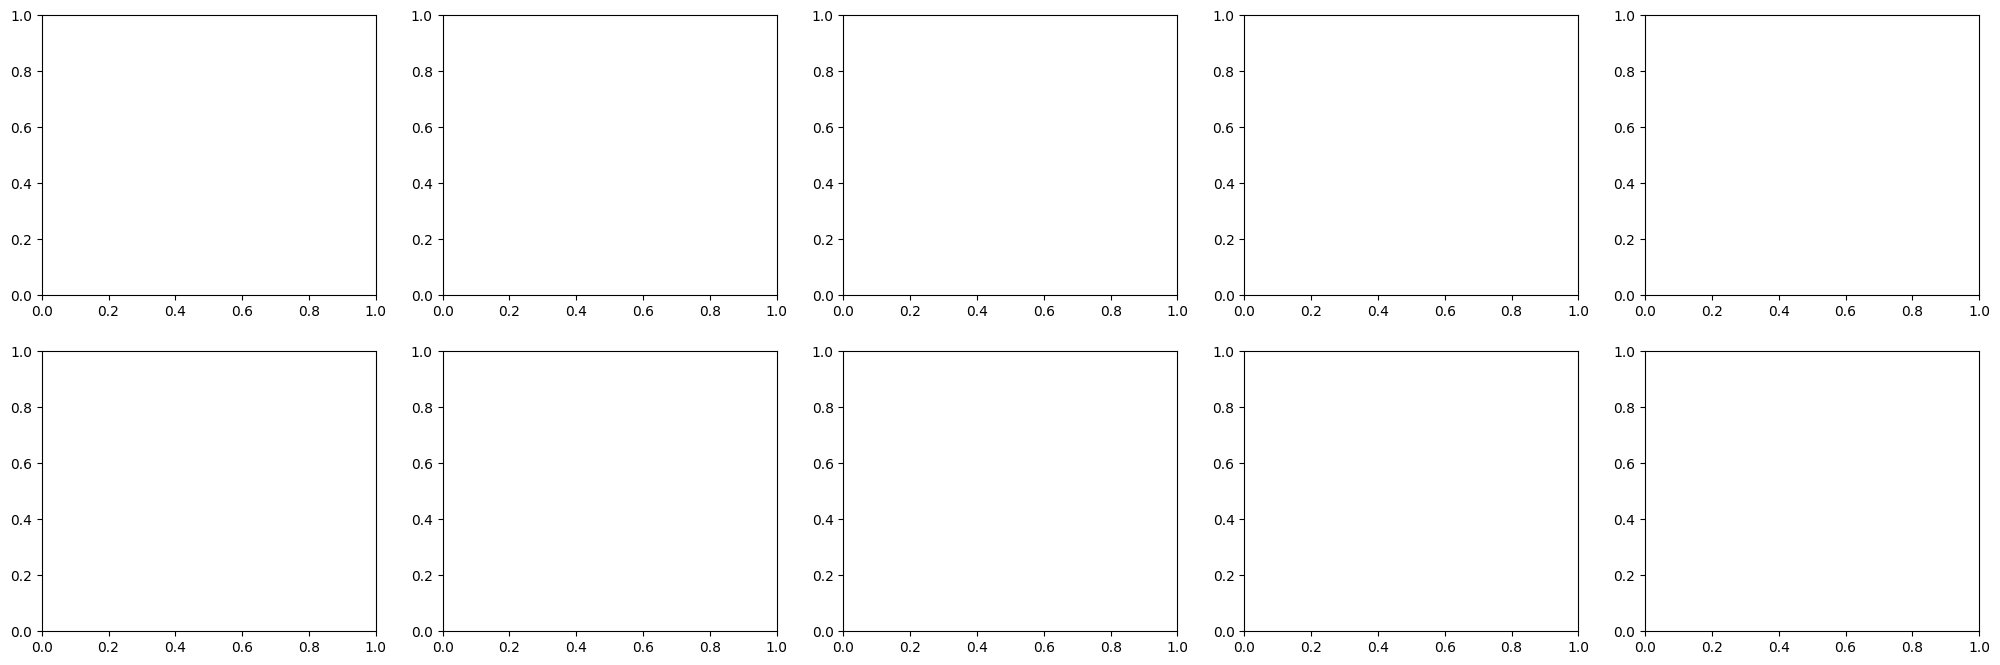

In [12]:
# Train FBRAC (Flow-based Actor-Critic with outer Q only, no inner critic)
plot_step = 10000
alpha=0.1


print("="*60)
print("Training FBRAC (Flow + Outer Q, no distillation) [JAX]")
print("="*60)
fbrac_outer_flow_params, fbrac_outer_critic_params, fbrac_outer_history = train_fbrac(
    x_1_data, rewards_data, 
    epochs=50000, 
    lr=3e-4, 
    alpha=alpha,  # BC regularization weight
    hidden=512,
    flow_steps=FLOW_STEPS,
    plot_every=plot_step  # Plot every 1000 epochs
)
print(f"Final Q at flow output: {fbrac_outer_history['flow_q_val'][-1]:.4f}")

Training fbrac_inner (Value Distillation) [JAX]


fbrac_inner (JAX): 100%|██████████| 50000/50000 [04:27<00:00, 187.03it/s]


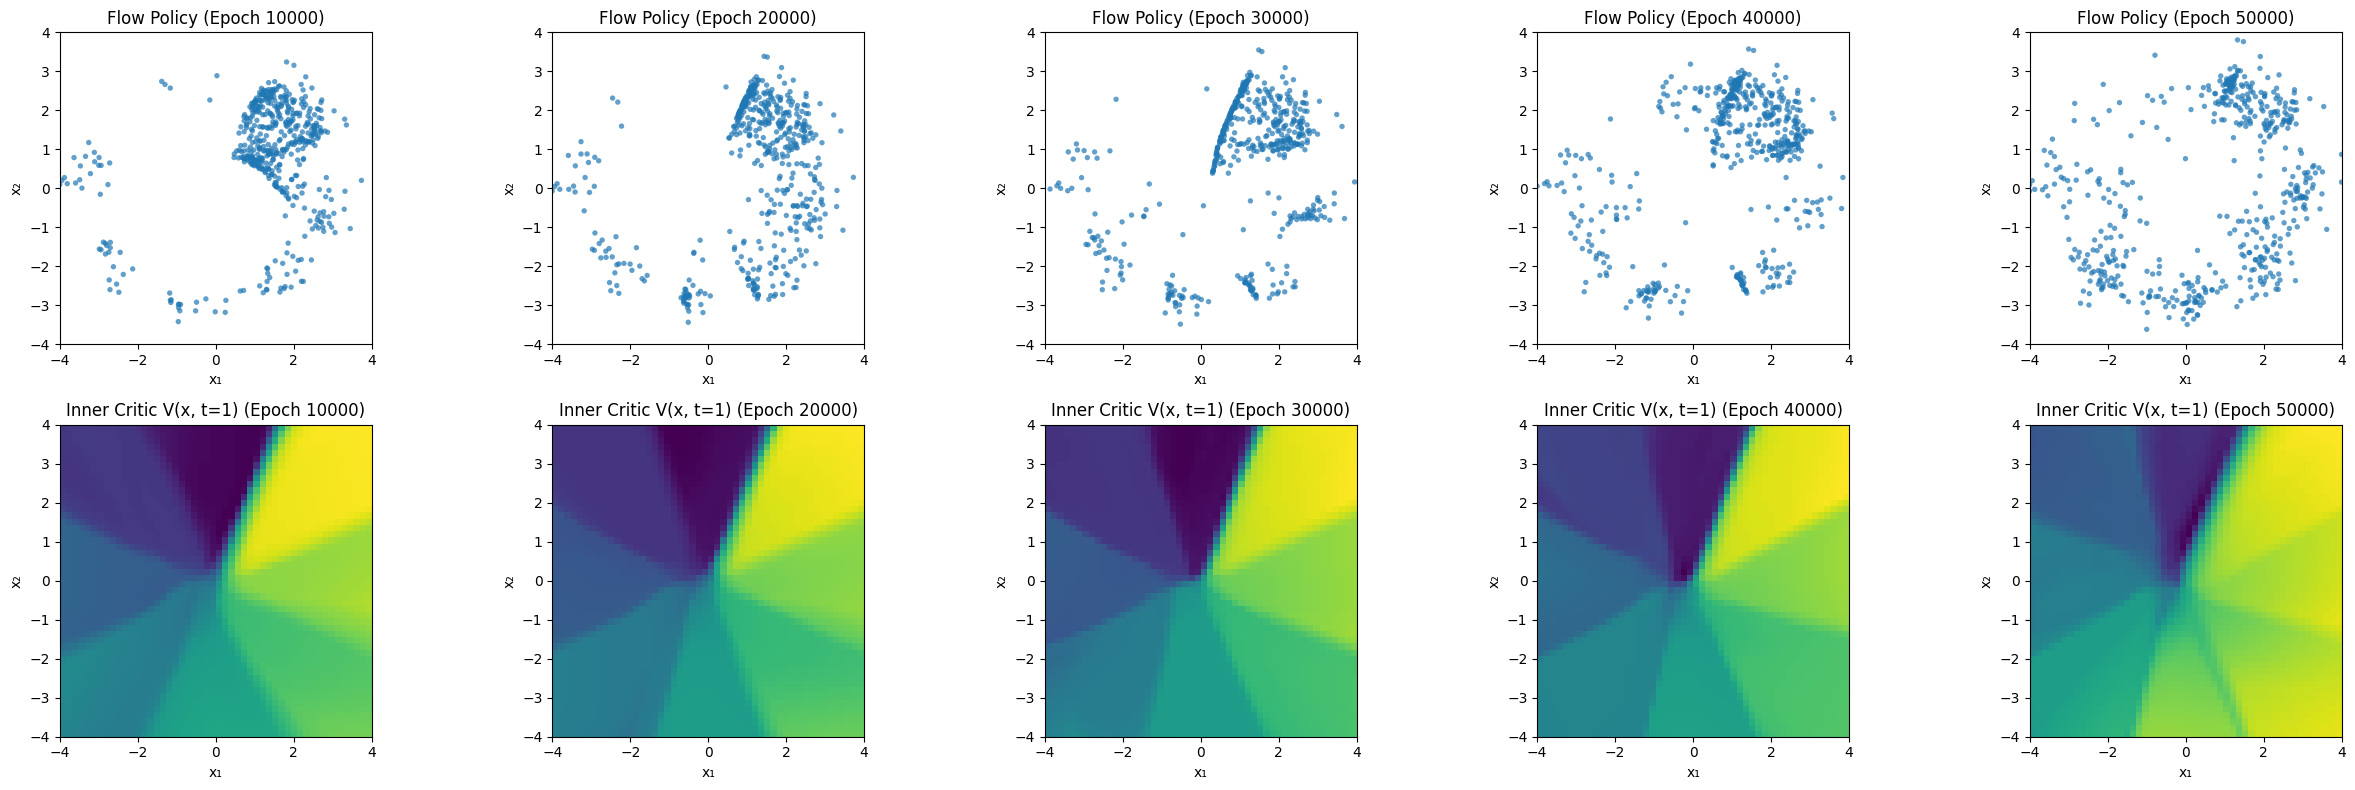

Final V at noise: 0.0000


In [ ]:
epochs=10000
num_plots = 5
plot_step = epochs // num_plots
print("="*60)
print("Training fbrac_inner (Value Distillation) [JAX]")
print("="*60)
alpha=0.3

fbrac_inner_flow_params, fbrac_inner_critic_params, fbrac_history = train_fbrac_inner(
    x_1_data, rewards_data, 
    epochs=epochs,
    lr=3e-4,
    alpha=alpha,  # Weight for V-maximization
    flow_steps=FLOW_STEPS,
    plot_every=plot_step,  # Plot every 1000 epochs
    use_time_embed=True,
    time_embed_dim=16,
    hidden=512,
    max_time_penalty=0.0,
    time_weight=False,
    use_residual=False,
    fbrac_inner_policy_loss_type="vgg_flow_matching",
    expectile=0.5
)
print(f"Final V at noise: {fbrac_history['flow_q_loss'][-1]:.4f}")

Training fbrac_inner_hlgauss (HL-Gauss Outer, Scalar Inner) [JAX]


fbrac_inner_hlgauss (JAX): 100%|██████████| 5000/5000 [00:25<00:00, 199.97it/s]


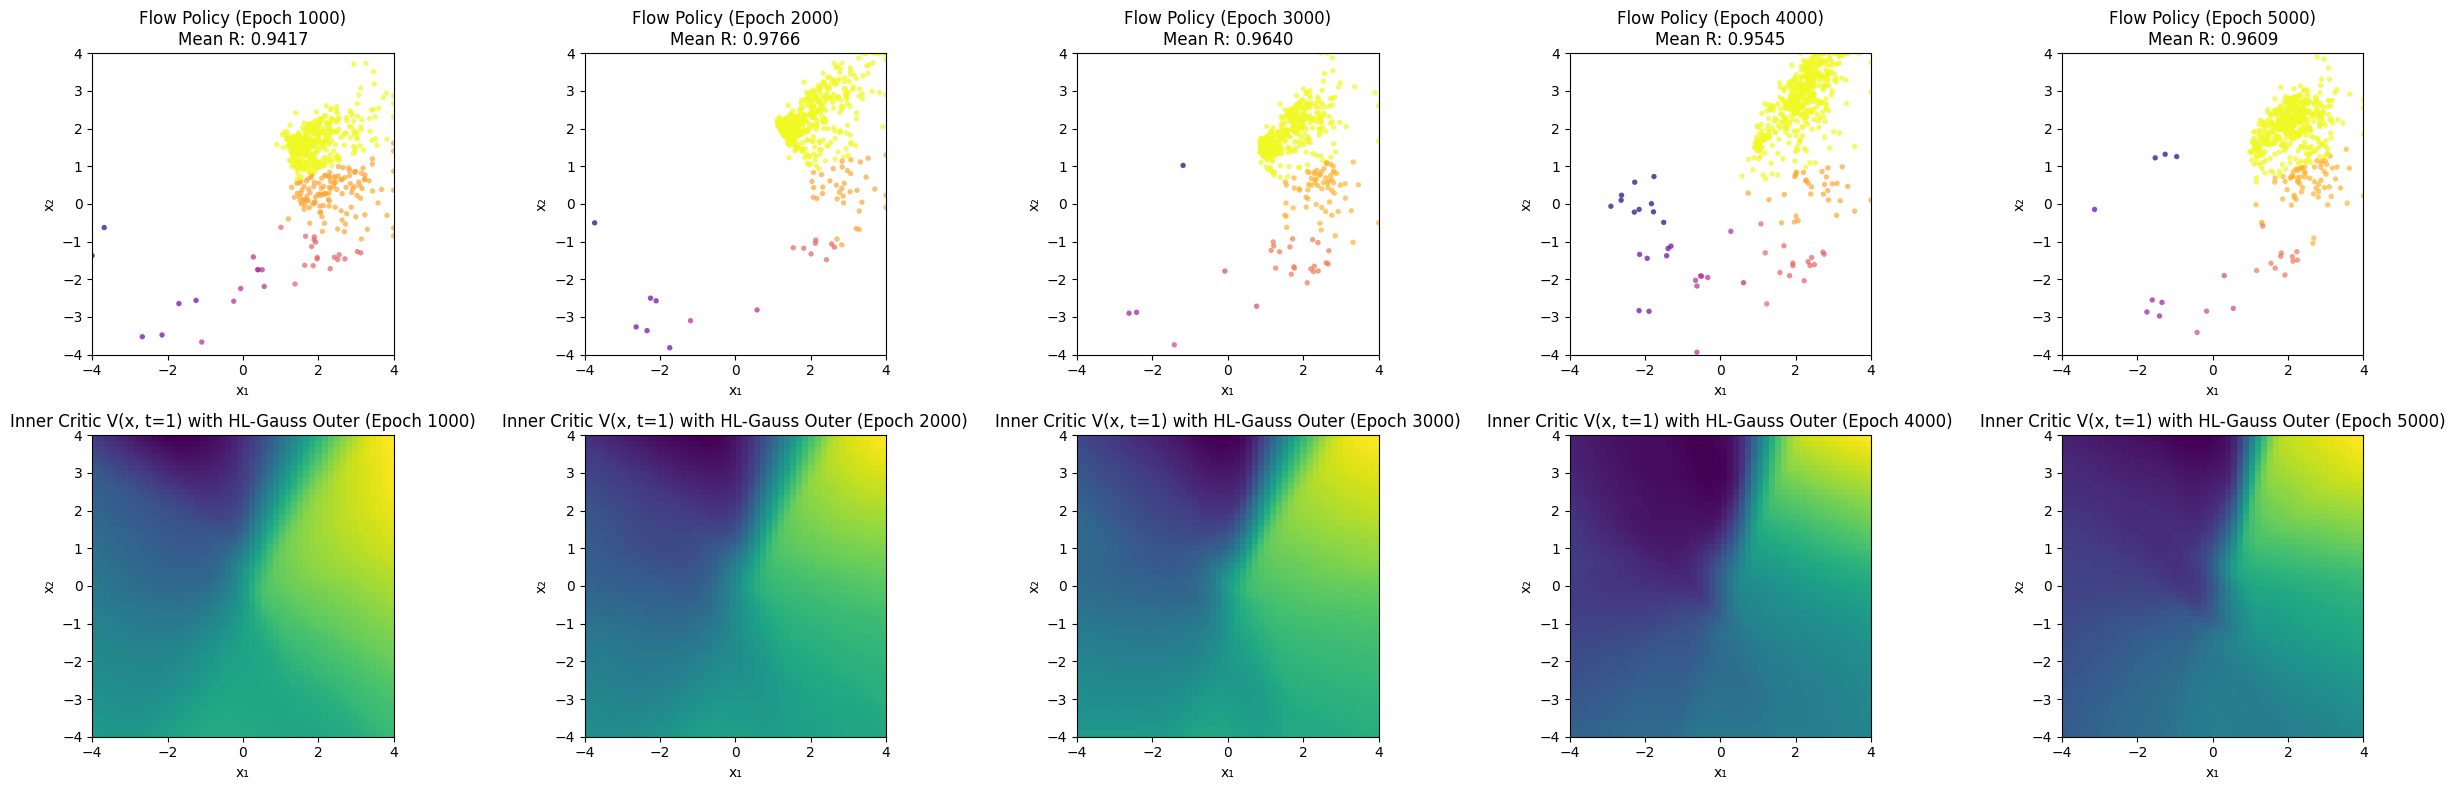

Final training complete. Final Q loss: 0.0000


In [19]:
plot_step = 1000
print("="*60)
print("Training fbrac_inner_hlgauss (HL-Gauss Outer, Scalar Inner) [JAX]")
print("="*60)
alpha=0.1

fbrac_hlgauss_flow, fbrac_hlgauss_inner, fbrac_hlgauss_outer, fbrac_hlgauss_history = train_fbrac_inner_hlgauss(
    x_1_data, rewards_data, 
    epochs=5000,
    lr=3e-4,
    alpha=alpha,  # Weight for V-maximization
    flow_steps=FLOW_STEPS,
    plot_every=plot_step,  # Plot every 2000 epochs
    use_time_embed=True,  # Use Fourier embedding for inner critic
    time_embed_dim=16,
    hidden=256,
    max_time_penalty=0.0,
    time_weight=False,
    fbrac_inner_policy_loss_type="vgg_flow_matching",
    expectile=0.5,
    num_bins=51,  # Number of bins for HL-Gauss
    q_min=-10.0,  # Minimum Q-value
    q_max=10.0,   # Maximum Q-value
    hl_gauss_sigma_ratio=8  # Paper default
)
print(f"Final training complete. Final Q loss: {fbrac_hlgauss_history['flow_q_loss'][-1]:.4f}")



In [11]:
# Evaluate Policy Quality (JAX)
n_eval = 512
key_eval = jrandom.PRNGKey(np.random.randint(0, 1000000))

z_eval = jrandom.normal(key_eval, (n_eval, 2))

# FQL: One-step policy
fql_actions = np.array(onestep_forward(fql_policy_params, z_eval))
fql_rewards = np.array(reward_fn_vec(jnp.asarray(fql_actions)))

# FQL: Flow teacher (for comparison)
fql_flow_actions = np.array(integrate_flow(fql_flow_params, z_eval, steps=FLOW_STEPS))
fql_flow_rewards = np.array(reward_fn_vec(jnp.asarray(fql_flow_actions)))

# fbrac_inner: Flow policy
fbrac_inner_actions = np.array(integrate_flow(fbrac_flow_params, z_eval, steps=FLOW_STEPS))
fbrac_inner_rewards = np.array(reward_fn_vec(jnp.asarray(fbrac_inner_actions)))

# fbrac_outer: Flow policy
fbrac_outer_actions = np.array(integrate_flow(fbrac_outer_flow_params, z_eval, steps=FLOW_STEPS))
fbrac_outer_rewards = np.array(reward_fn_vec(jnp.asarray(fbrac_outer_actions)))

print("="*60)
print("POLICY QUALITY (Mean Reward of Generated Actions)")
print("="*60)
print(f"Dataset (ground truth):    {rewards_data.mean():.4f}")
print(f"FQL One-Step Policy:       {fql_rewards.mean():.4f}")
print(f"FQL Flow Teacher:          {fql_flow_rewards.mean():.4f}")
print(f"fbrac_inner Flow Policy:   {fbrac_inner_rewards.mean():.4f}")
print(f"fbrac_outer Flow Policy:   {fbrac_outer_rewards.mean():.4f}")

POLICY QUALITY (Mean Reward of Generated Actions)
Dataset (ground truth):    0.5070
FQL One-Step Policy:       0.8206
FQL Flow Teacher:          0.5061
fbrac_inner Flow Policy:   0.9785
fbrac_outer Flow Policy:   0.8557


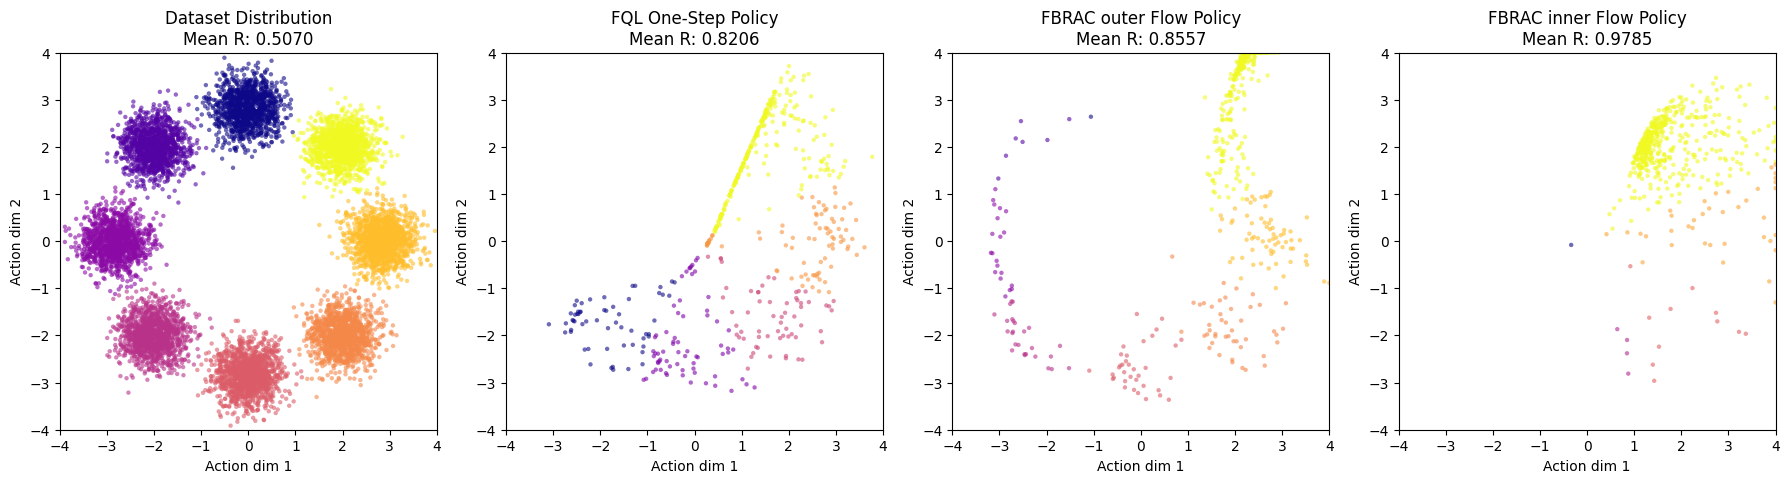

In [12]:
# Visualize Relevant Results
fig, axes = plt.subplots(1, 4, figsize=(18, 10))
axis_limits = [DOMAIN_MIN, DOMAIN_MAX]

# 0. Dataset Distribution
ax0 = axes[0]
ax0.scatter(x_1_data[:, 0], x_1_data[:, 1], c=rewards_data, cmap='plasma', 
            s=10, alpha=0.6, edgecolors='none')
ax0.set_title(f'Dataset Distribution\nMean R: {rewards_data.mean():.4f}')
ax0.set_xlabel('Action dim 1'); ax0.set_ylabel('Action dim 2')
ax0.set_xlim(axis_limits); ax0.set_ylim(axis_limits); ax0.set_aspect('equal')

# 1. FQL One-Step Policy
ax1 = axes[1]
ax1.scatter(fql_actions[:, 0], fql_actions[:, 1], c=fql_rewards, cmap='plasma', 
            s=10, alpha=0.6, edgecolors='none')
ax1.set_title(f'FQL One-Step Policy\nMean R: {fql_rewards.mean():.4f}')
ax1.set_xlabel('Action dim 1'); ax1.set_ylabel('Action dim 2')
ax1.set_xlim(axis_limits); ax1.set_ylim(axis_limits); ax1.set_aspect('equal')

# 3. fbrac_outer Flow Policy
ax3 = axes[2]
ax3.scatter(fbrac_outer_actions[:, 0], fbrac_outer_actions[:, 1], c=fbrac_outer_rewards, cmap='plasma', 
            s=10, alpha=0.6, edgecolors='none')
ax3.set_title(f'FBRAC outer Flow Policy\nMean R: {fbrac_outer_rewards.mean():.4f}')
ax3.set_xlabel('Action dim 1'); ax3.set_ylabel('Action dim 2')
ax3.set_xlim(axis_limits); ax3.set_ylim(axis_limits); ax3.set_aspect('equal')

# 2. fbrac_inner Flow Policy
ax2 = axes[3]
ax2.scatter(fbrac_inner_actions[:, 0], fbrac_inner_actions[:, 1], c=fbrac_inner_rewards, cmap='plasma', 
            s=10, alpha=0.6, edgecolors='none')
ax2.set_title(f'FBRAC inner Flow Policy\nMean R: {fbrac_inner_rewards.mean():.4f}')
ax2.set_xlabel('Action dim 1'); ax2.set_ylabel('Action dim 2')
ax2.set_xlim(axis_limits); ax2.set_ylim(axis_limits); ax2.set_aspect('equal')

plt.tight_layout()
plt.show()

In [14]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

# 1. Helper for fbrac_inner V-value with time embedding
def _inner_critic_forward_plotting(params, x, t):
    # Consistently use time_embed_dim=16 as in the training call
    t_embed = fourier_time_embed(t, embed_dim=16)
    xt = jnp.concatenate([x, t_embed], axis=-1)
    return apply_mlp(params, xt).squeeze(-1)

# 2. Evaluation Setup
n_eval_traj = 128
key_traj = jax.random.PRNGKey(np.random.randint(0, 1000))
z_init = jax.random.normal(key_traj, (n_eval_traj, 2))

# 3. Collect fbrac_inner Trajectory Values
v_inner_history = []
x_inner = z_init
times = jnp.linspace(0.0, 1.0, FLOW_STEPS + 1)

for t_val in times:
    t_batch = jnp.full((n_eval_traj, 1), t_val)
    t_embed = fourier_time_embed(t_batch, embed_dim=16)
    v_val = _inner_critic_forward_plotting(fbrac_inner_critic_params, x_inner, t_batch)
    v_inner_history.append(v_val)
    
    if t_val < 1.0:
        dt = 1.0 / FLOW_STEPS
        v_flow = flow_forward(fbrac_inner_flow_params, x_inner, t_batch)
        x_inner = x_inner + v_flow * dt
        x_inner = jnp.clip(x_inner, DOMAIN_MIN, DOMAIN_MAX)

v_inner_history = jnp.array(v_inner_history)
v_inner_err = jnp.abs(v_inner_history - v_inner_history[-1,:]).mean(axis=-1)

# 4. Collect fbrac_outer Trajectory Values (integrated Q)
v_outer_history = []
x_outer = z_init

for t_val in times:
    t_batch = jnp.full((n_eval_traj, 1), t_val)
    q_val = critic_forward(fbrac_outer_critic_params, x_outer)
    v_outer_history.append(q_val)
    
    if t_val < 1.0:
        dt = 1.0 / FLOW_STEPS
        v_flow = flow_forward(fbrac_outer_flow_params, x_outer, t_batch)
        x_outer = x_outer + v_flow * dt
        x_outer = jnp.clip(x_outer, DOMAIN_MIN, DOMAIN_MAX)

v_outer_history = jnp.array(v_outer_history)
v_outer_err = jnp.abs(v_outer_history - v_outer_history[-1,:]).mean(axis=-1)

# 5. Plotting
plt.figure(figsize=(8, 5))
plt.plot(times, v_inner_err, label="Inner Value V(x_t,t) (state-value)", marker='o')
plt.plot(times, v_outer_err, label="Outer Value Q(x_t)", marker='s')
plt.xlabel("Time (t)")
plt.ylabel("Absolute Difference")
plt.title("|V(x_1) - V(x_t)| along Policy Trajectory (Average)")
plt.legend()
plt.grid(True)
plt.show()

print("Trajectory Value Comparison Plot complete.")


NameError: name 'fbrac_outer_critic_params' is not defined

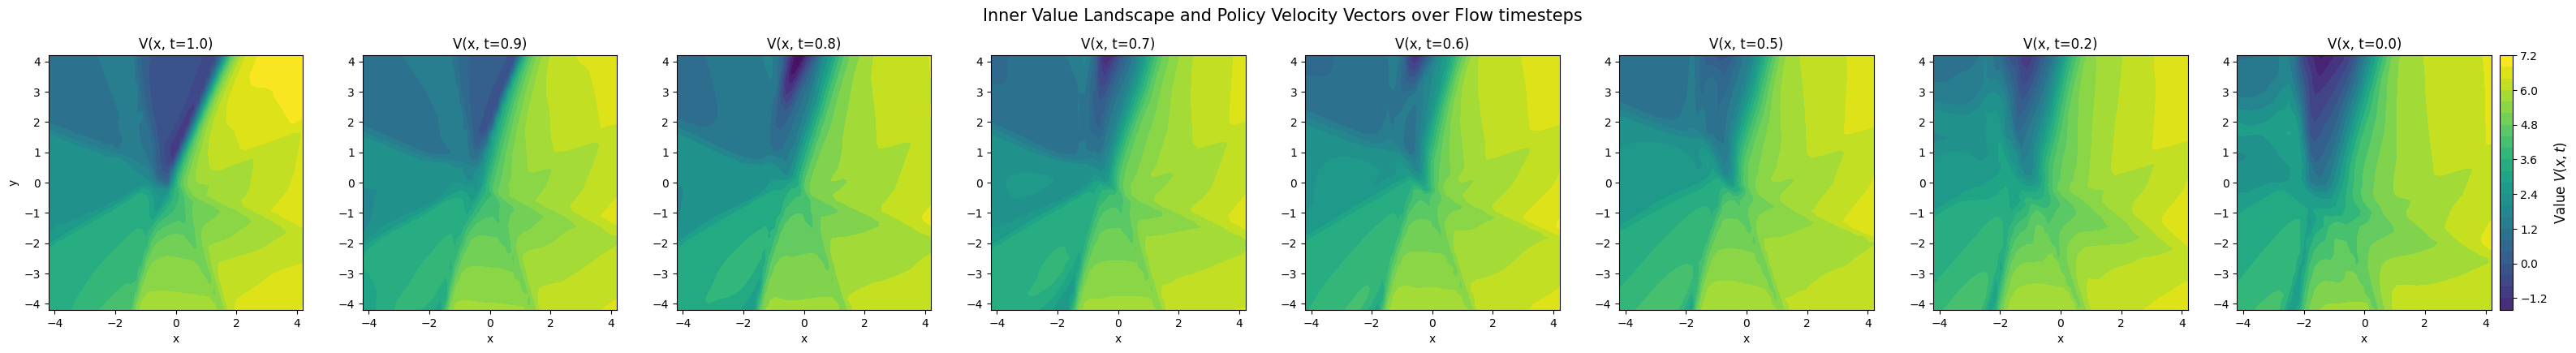

In [15]:
# ============================================================================
# PLOT FBRAC_INNER Q LANDSCAPE AND POLICY VELOCITIES OVER SAMPLING TIMESTEPS
# ============================================================================

# Settings
resolution = 50
plot_range = 4.2
timesteps = [1.0, 0.9, 0.8, 0.7, 0.6 , 0.5, 0.2, 0.0]


# Create grid of positions (x)
xs = np.linspace(-plot_range, plot_range, resolution)
ys = np.linspace(-plot_range, plot_range, resolution)
X, Y = np.meshgrid(xs, ys)
positions = np.stack([X.flatten(), Y.flatten()], axis=1)
positions_tensor = jnp.asarray(positions)

# Evaluate fbrac_inner critic and inner policy velocities at each timestep
fbrac_inner_V = {}
fbrac_inner_vels = {}

for t_val in timesteps:
    t_tensor = jnp.full((positions_tensor.shape[0], 1), t_val)
    t_embed = fourier_time_embed(t_tensor, embed_dim=16)

    # Value
    v = inner_critic_forward(fbrac_inner_critic_params, positions_tensor, t_embed) * 8
    fbrac_inner_V[t_val] = np.array(v).reshape(X.shape)

    # Policy velocity: model predicts v, so velocity = v / FLOW_STEPS
    velocity = flow_forward(fbrac_inner_flow_params, positions_tensor, t_tensor)
    velocity = np.array(velocity) / FLOW_STEPS   # scale for delta x per step
    fbrac_inner_vels[t_val] = velocity.reshape((X.shape[0], X.shape[1], 2))

# Add: Get global vmin/vmax for all the value plots for consistent colorbar scaling
all_V = np.array([fbrac_inner_V[t] for t in timesteps])
vmin = np.min(all_V)
vmax = np.max(all_V)

# Plot: one row, columns = timesteps, with velocity vectors overlaid
fig, axes = plt.subplots(1, len(timesteps), figsize=(4*len(timesteps), 4))

# To share single colorbar, collect all im objects
ims = []

for col, t_val in enumerate(timesteps):
    ax = axes[col]
    im = ax.contourf(X, Y, fbrac_inner_V[t_val], levels=20, cmap='viridis', vmin=vmin, vmax=vmax)
    ims.append(im)
    ax.set_title(f'V(x, t={t_val})')
    ax.set_aspect('equal')
    ax.set_xlim(-plot_range, plot_range)
    ax.set_ylim(-plot_range, plot_range)
    if col == 0:
        ax.set_ylabel('y')
    ax.set_xlabel('x')

    # Overlay velocities (quiver)
    # vel = fbrac_inner_vels[t_val]
    # skip = (slice(None, None, 3), slice(None, None, 3))  # sparsify for visualization
    # # reshape for quiver: X, Y, U, V must all be shape (res, res)
    # ax.quiver(
    #     X[skip], Y[skip],
    #     vel[...,0][skip], vel[...,1][skip],
    #     color='red', scale=0.5/np.max(np.linalg.norm(vel, axis=-1)) if np.max(np.linalg.norm(vel, axis=-1)) > 0 else 1,
    #     width=0.004, alpha=0.7, headwidth=3, headlength=4, headaxislength=3
    # )

# Add a colorbar for the contourf plots (the value) on the right-hand side
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Make sure axes is always a numpy array
axes = np.array(axes)

# Place colorbar axis on the right of the last subplot
divider = make_axes_locatable(axes[-1])
cax = divider.append_axes("right", size="5%", pad=0.10)
cbar = fig.colorbar(ims[0], cax=cax)
cbar.set_label("Value $V(x, t)$", fontsize=12)

plt.suptitle('Inner Value Landscape and Policy Velocity Vectors over Flow timesteps', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================================
# PLOT FBRAC_INNER Q LANDSCAPE AND POLICY VELOCITIES OVER SAMPLING TIMESTEPS
# ============================================================================

# Settings
resolution = 50
plot_range = 4.2
timesteps = [1.0, 0.9, 0.8, 0.7, 0.6 , 0.5, 0.2, 0.0]


# Create grid of positions (x)
xs = np.linspace(-plot_range, plot_range, resolution)
ys = np.linspace(-plot_range, plot_range, resolution)
X, Y = np.meshgrid(xs, ys)
positions = np.stack([X.flatten(), Y.flatten()], axis=1)
positions_tensor = jnp.asarray(positions)

# Evaluate fbrac_inner critic and inner policy velocities at each timestep
fbrac_inner_V = {}
fbrac_inner_vels = {}

for t_val in timesteps:
    t_tensor = jnp.full((positions_tensor.shape[0], 1), t_val)
    t_embed = fourier_time_embed(t_tensor, embed_dim=16)

    # Value
    v = inner_critic_forward(fbrac_inner_critic_params, positions_tensor, t_embed) * 8
    fbrac_inner_V[t_val] = np.array(v).reshape(X.shape)

    # Policy velocity: model predicts v, so velocity = v / FLOW_STEPS
    velocity = flow_forward(fbrac_inner_flow_params, positions_tensor, t_tensor)
    velocity = np.array(velocity) / FLOW_STEPS   # scale for delta x per step
    fbrac_inner_vels[t_val] = velocity.reshape((X.shape[0], X.shape[1], 2))

# Add: Get global vmin/vmax for all the value plots for consistent colorbar scaling
all_V = np.array([fbrac_inner_V[t] for t in timesteps])
vmin = np.min(all_V)
vmax = np.max(all_V)

# Plot: one row, columns = timesteps, with velocity vectors overlaid
fig, axes = plt.subplots(1, len(timesteps), figsize=(4*len(timesteps), 4))

# To share single colorbar, collect all im objects
ims = []

for col, t_val in enumerate(timesteps):
    ax = axes[col]
    im = ax.contourf(X, Y, fbrac_inner_V[t_val], levels=20, cmap='viridis', vmin=vmin, vmax=vmax)
    ims.append(im)
    ax.set_title(f'V(x, t={t_val})')
    ax.set_aspect('equal')
    ax.set_xlim(-plot_range, plot_range)
    ax.set_ylim(-plot_range, plot_range)
    if col == 0:
        ax.set_ylabel('y')
    ax.set_xlabel('x')

    # Overlay velocities (quiver)
    # vel = fbrac_inner_vels[t_val]
    # skip = (slice(None, None, 3), slice(None, None, 3))  # sparsify for visualization
    # # reshape for quiver: X, Y, U, V must all be shape (res, res)
    # ax.quiver(
    #     X[skip], Y[skip],
    #     vel[...,0][skip], vel[...,1][skip],
    #     color='red', scale=0.5/np.max(np.linalg.norm(vel, axis=-1)) if np.max(np.linalg.norm(vel, axis=-1)) > 0 else 1,
    #     width=0.004, alpha=0.7, headwidth=3, headlength=4, headaxislength=3
    # )

# Add a colorbar for the contourf plots (the value) on the right-hand side
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Make sure axes is always a numpy array
axes = np.array(axes)

# Place colorbar axis on the right of the last subplot
divider = make_axes_locatable(axes[-1])
cax = divider.append_axes("right", size="5%", pad=0.10)
cbar = fig.colorbar(ims[0], cax=cax)
cbar.set_label("Value $V(x, t)$", fontsize=12)

plt.suptitle('Inner Value Landscape and Policy Velocity Vectors over Flow timesteps', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

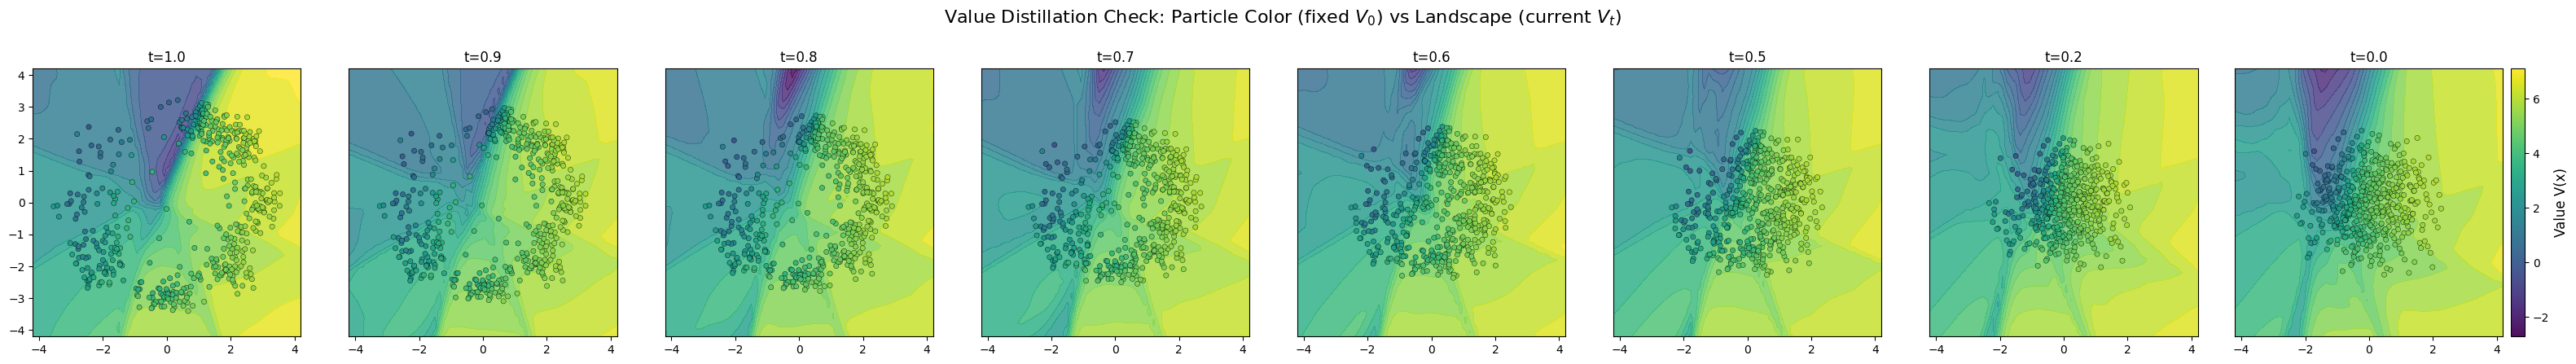

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import jax.numpy as jnp
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.stats import norm

# ============================================================================
# 1. SIMULATION CONFIGURATION
# ============================================================================
# Assuming FLOW_STEPS is defined globally as before
# FLOW_STEPS = 100

# We plot these specific timestamps (ordered 0.0 -> 1.0 for the flow direction)
timesteps_to_plot = [0.0, 0.2, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0][::-1]

# Instead of meshgrid, directly sample a Gaussian-shaped grid for N(0, I)
init_num = 512  # Number of particles (higher = denser cloud)
rng = np.random.default_rng(0)  # For reproducibility

# Use quantile grid in 1D then stack, but *not* meshgrid: just 2D points in a disk from N(0,1)
probs = np.linspace(0.01, 0.99, init_num+2)[1:-1]  # strictly avoid endpoints
quantiles_1d = norm.ppf(probs)
# Randomly sample pairs
particle_idx = np.arange(init_num)
xs = quantiles_1d[rng.choice(init_num, init_num, replace=False)]
ys = quantiles_1d[rng.choice(init_num, init_num, replace=False)]
particles = np.stack([xs, ys], axis=1)

# Optional: Mask out extreme outliers in radius if desired
radius = 3.5
r2 = np.sum(particles ** 2, axis=1)
mask = r2 < radius**2
particles_masked = particles.copy()
particles_masked[~mask] = np.nan  # will be removed in plotting

# Convert to JAX array
particles_curr = jnp.asarray(particles_masked)

# ============================================================================
# 2. CALCULATE INITIAL VALUES AT T=0 (THE "IDENTITY")
# ============================================================================
# We calculate V at t=0 (Noise) for these particles and FREEZE this value.
# This serves as the "tracker ID" for the particle.
t_init = jnp.full((particles_curr.shape[0], 1), 0.0)
t_embed_init = fourier_time_embed(t_init, embed_dim=16)

# Value at start (t=0)
# This color will stick to the particle throughout the simulation
values_init = inner_critic_forward(fbrac_inner_critic_params, particles_curr, t_embed_init) * 8
particle_colors = np.array(values_init).flatten()

# ============================================================================
# 3. PUSH FORWARD (INTEGRATION 0 -> 1)
# ============================================================================
particle_history = {0.0: particles_masked.copy()}
current_x = particles_curr

for step in range(FLOW_STEPS):
    t_val = step / FLOW_STEPS

    t_tensor = jnp.full((current_x.shape[0], 1), t_val)
    step_displacement = flow_forward(fbrac_inner_flow_params, current_x, t_tensor)
    step_displacement = step_displacement / FLOW_STEPS

    nan_mask = jnp.isnan(current_x[:, 0]) | jnp.isnan(current_x[:, 1])
    next_x = current_x + step_displacement
    next_x = jnp.where(nan_mask[:, None], jnp.nan, next_x)
    current_x = next_x

    next_t = (step + 1) / FLOW_STEPS
    for p_t in timesteps_to_plot:
        if abs(next_t - p_t) < (0.5 / FLOW_STEPS):
            particle_history[p_t] = np.array(current_x)

particle_history[1.0] = np.array(current_x)

# ============================================================================
# 4. PLOT: CONSISTENCY CHECK
# ============================================================================

# 1. Pre-calculate landscape backgrounds for global color scaling
landscape_values = []
bg_res = 60
bg_xs = np.linspace(-4.2, 4.2, bg_res)
bg_ys = np.linspace(-4.2, 4.2, bg_res)
bg_X, bg_Y = np.meshgrid(bg_xs, bg_ys)
bg_pos = np.stack([bg_X.flatten(), bg_Y.flatten()], axis=1)
bg_pos_tensor = jnp.asarray(bg_pos)

bg_frames = {}
for t in timesteps_to_plot:
    t_in = jnp.full((bg_pos_tensor.shape[0], 1), t)
    t_emb = fourier_time_embed(t_in, embed_dim=16)
    v = inner_critic_forward(fbrac_inner_critic_params, bg_pos_tensor, t_emb) * 8
    bg_frames[t] = np.array(v).reshape(bg_X.shape)
    landscape_values.append(bg_frames[t])

# Only count non-NaN values for colorbar range
all_particle_vals = particle_colors[~np.isnan(particles_masked[:, 0])]
all_vals = np.concatenate([np.array(landscape_values).flatten(), all_particle_vals])
vmin, vmax = np.nanmin(all_vals), np.nanmax(all_vals)

# 2. Setup Plot
fig, axes = plt.subplots(1, len(timesteps_to_plot), figsize=(4 * len(timesteps_to_plot), 4))

for col, t_val in enumerate(timesteps_to_plot):
    ax = axes[col]

    # A. Background: Value Landscape at current t
    im = ax.contourf(bg_X, bg_Y, bg_frames[t_val], levels=20,
                     cmap='viridis', vmin=vmin, vmax=vmax, alpha=0.8)

    # B. Foreground: Particles at current t
    if t_val in particle_history:
        p_pos = particle_history[t_val]

        good = ~np.isnan(p_pos[:, 0]) & ~np.isnan(p_pos[:, 1])
        sc = ax.scatter(p_pos[good, 0], p_pos[good, 1], c=particle_colors[good],
                        cmap='viridis', vmin=vmin, vmax=vmax,
                        s=20, edgecolor='black', linewidth=0.3, alpha=0.95)

    ax.set_title(f't={t_val:.1f}')
    ax.set_aspect('equal')
    ax.set_xlim(-4.2, 4.2)
    ax.set_ylim(-4.2, 4.2)
    if col > 0:
        ax.yaxis.set_visible(False)

# Add shared colorbar
divider = make_axes_locatable(axes[-1])
cax = divider.append_axes("right", size="5%", pad=0.10)
cbar = fig.colorbar(sc, cax=cax)
cbar.set_label("Value V(x)", fontsize=12)

plt.suptitle(r'Value Distillation Check: Particle Color (fixed $V_0$) vs Landscape (current $V_t$)', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()